<h1 style="text-align: center;">
  Proyecto: Sistema Multimodal de Reconocimiento de Emociones
</h1>
<h5 style="text-align: center;">
    Nombre del alumno: Jose Francisco Juarez Aceves 
    <br>
    Materia: Ciencia de Datos para Sensores Inteligentes
</h5>

# 1. Recopilación de datos

Esta sección implementa la captura simultánea de señales EEG y ECG en tiempo real.
La adquisición multimodal es el punto de partida del proyecto y determina la calidad
de todo el análisis posterior.

### Decisiones de diseño

**Elección del hardware:** se eligió el Muse S para EEG por su accesibilidad económica
y sus 4 canales (TP9, AF7, AF8, TP10) que cubren las regiones frontales y temporales
más relevantes para el reconocimiento de emociones. El AD8232 se eligió para ECG por
su bajo costo y facilidad de integración con Arduino.

**Comunicación paralela:** el EEG se transmite vía Bluetooth Low Energy (BLE) usando
la librería `bleak` con callbacks asíncronos, mientras el ECG llega por puerto serial
USB. Ambos workers corren como corutinas `asyncio` para no bloquearse mutuamente.

**Timestamp de host:** cada muestra se etiqueta con `time.time_ns()` del sistema
operativo en el momento de recepción. Este timestamp compartido es la única forma
de sincronizar dos señales con relojes independientes.

**Formato de salida:** CSV en lugar de un formato binario para facilitar la inspección
manual, compatibilidad con pandas y reproducibilidad sin dependencias adicionales.


### Muse EEG + AD8232 ECG Recorder

Captura simultanea de EEG (Muse) y ECG (AD8232/Arduino) para reconocimiento multimodal de emociones.

In [1]:
import asyncio as aio
import csv
import datetime as dt
import re
import time
from collections import deque
from pathlib import Path

import bleak        
import numpy as np
import pandas as pd

import OpenMuse
from OpenMuse import find_muse
from OpenMuse.muse import MuseS
from OpenMuse.decode import parse_message, make_timestamps, select_eeg_channels

import matplotlib.pyplot as plt
from IPython.display import clear_output, display

%matplotlib inline

## Configuracion serial (AD8232)

- Linux: `/dev/ttyACM0`, `/dev/ttyUSB0`
- Windows: `COM3`, `COM4`, etc.

In [6]:
import serial

PORT     = "/dev/ttyACM1" # <-- cambia segun tu sistema
BAUDRATE = 115200

ser = serial.Serial(PORT, BAUDRATE, timeout=0.5)
print(f"Conectado a {PORT}")
time.sleep(2)
if ser.in_waiting:
    ser.reset_input_buffer()
print("Listo para lectura")

SerialException: [Errno 2] could not open port /dev/ttyACM1: [Errno 2] No such file or directory: '/dev/ttyACM1'

## Configuracion general

In [2]:
OUTPUT_DIR = Path("recordings")
OUTPUT_DIR.mkdir(exist_ok=True)

SCAN_TIMEOUT_SEC  = 12
MUSE_ADDRESS      = None
MUSE_DEVICE_INDEX = 0
MUSE_PRESET = "p1041"

ECG_FS             = 250   # Hz del Arduino — ajusta si es diferente
SERIAL_BUFFER_SIZE = 3000
LIVE_REFRESH_SEC   = 1.0

## Descubrir Muse

In [9]:
muse_candidates = find_muse(timeout=SCAN_TIMEOUT_SEC, verbose=True)
if MUSE_ADDRESS:
    muse_candidates = [m for m in muse_candidates
                       if m.get("address","").lower() == MUSE_ADDRESS.lower()]
if not muse_candidates:
    raise RuntimeError("No se encontro Muse.")
if MUSE_DEVICE_INDEX >= len(muse_candidates):
    raise IndexError("MUSE_DEVICE_INDEX fuera de rango.")
muse_address = muse_candidates[MUSE_DEVICE_INDEX]["address"]
print(f"Muse seleccionado: {muse_address}")

Searching for Muses (max. 12 seconds)...
Found device MuseS-F963, MAC Address 00:55:DA:B9:F9:63
Muse seleccionado: 00:55:DA:B9:F9:63


## Workers de grabación

Cada modalidad tiene su propio worker asíncrono que corre en paralelo.

### Decisiones de diseño

**`_serial_ecg_worker`:** lee el puerto serial línea por línea usando
`asyncio.to_thread(ser.readline)` para no bloquear el event loop. El Arduino envía
el valor ADC crudo en cada ciclo y, cuando detecta un latido, agrega el BPM separado
por coma (`523,72`). El worker parsea este formato y usa el BPM del Arduino como
primera fuente de HR; el `RRDetector` del notebook sirve como fallback si el BPM
no viene en la línea.

**`_openmuse_eeg_worker`:** usa una cola `asyncio.Queue` como buffer entre el callback
BLE (que puede llamarse desde cualquier hilo) y el procesamiento en el event loop.
El tamaño máximo de la cola es 50,000 paquetes para absorber picos de latencia.

**`RRDetector`:** detector adaptativo de picos R con ventana deslizante de 3 segundos.
El threshold `media + 1.2 × std` se recalcula en cada muestra para adaptarse a cambios
de amplitud. La bandera `_above` implementa detección por flanco (evita múltiples
disparos en el mismo pico).

| Variable | Descripción |
|---|---|
| **HR** | Frecuencia cardíaca media (bpm) |
| **HRV** | Variabilidad cardíaca (= SDNN, ms) |
| **RMSSD** | Raíz cuadrada de la media de diferencias cuadráticas sucesivas de RR (ms) |
| **SDNN** | Desviación estándar de los intervalos RR acumulados (ms) |


In [3]:
# ─── Estado global ────────────────────────────────────────────
recording_stop_event = None
recording_tasks      = {}
recording_paths      = {}
recording_stats      = {}
live_buffers         = {}

def _utc_iso_from_ns(ts_ns: int) -> str:
    return dt.datetime.fromtimestamp(ts_ns / 1e9, tz=dt.timezone.utc).isoformat().replace("+00:00", "Z")

def _extract_ecg_value(line: str):
    """Parsea 'raw' o 'raw,bpm' desde el serial."""
    parts = line.strip().split(",")
    try:
        ecg = float(parts[0])
    except (ValueError, IndexError):
        return None, None
    bpm = None
    if len(parts) >= 2:
        try:
            bpm = float(parts[1])
        except ValueError:
            pass
    return ecg, bpm

# ─── Detector de picos R ──────────────────────────────────────
class RRDetector:
    def __init__(self, fs=250.0, min_rr_ms=400.0):
        self.fs           = fs
        self.min_gap      = int(fs * min_rr_ms / 1000)
        self.threshold    = None
        self.last_peak    = -int(fs * min_rr_ms / 1000)
        self.window       = deque(maxlen=int(fs * 3))
        self.sample_idx   = 0
        self.rr_intervals = deque(maxlen=300)
        self._above       = False

    def update(self, value):
        self.window.append(value)
        self.sample_idx += 1

        if len(self.window) < int(self.fs * 2):
            return None

        arr = np.array(self.window)
        self.threshold = arr.mean() + 1.2 * arr.std()

        rr_ms = None
        gap   = self.sample_idx - self.last_peak

        if value > self.threshold and not self._above and gap >= self.min_gap:
            self._above = True
            if self.last_peak > 0:
                rr_ms = gap / self.fs * 1000.0
                if 300 < rr_ms < 1500:
                    self.rr_intervals.append(rr_ms)
                    self.last_peak = self.sample_idx
                    return rr_ms
            else:
                self.last_peak = self.sample_idx
        elif value < self.threshold:
            self._above = False

        return None

    def compute_metrics(self):  # <-- este faltaba
        rr = np.array(self.rr_intervals)
        if len(rr) < 2:
            return {"hr": None, "hrv": None, "rmssd": None, "sdnn": None}
        hr    = 60_000.0 / rr.mean()
        sdnn  = float(rr.std())
        hrv   = sdnn
        rmssd = float(np.sqrt(np.mean(np.diff(rr) ** 2)))
        return {"hr": round(hr,2), "hrv": round(hrv,2),
                "rmssd": round(rmssd,2), "sdnn": round(sdnn,2)}

# ─── Worker serial ECG (AD8232) ───────────────────────────────
async def _serial_ecg_worker(ser, ecg_csv_path, stop_event, stats, buffers):
    detector = RRDetector(fs=ECG_FS)

    def _extract_ecg_value(line: str):
        """Parsea 'raw' o 'raw,bpm' desde el serial."""
        parts = line.strip().split(",")
        try:
            ecg = float(parts[0])
        except (ValueError, IndexError):
            return None, None
        bpm = None
        if len(parts) >= 2:
            try:
                bpm = float(parts[1])
            except ValueError:
                pass
        return ecg, bpm

    with ecg_csv_path.open("w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow([
            "host_time_utc", "host_time_ns",
            "ecg_raw", "rr_ms", "hr_bpm", "hrv_ms", "rmssd_ms", "sdnn_ms",
        ])
        rows = 0
        while not stop_event.is_set():
            try:
                raw = await aio.to_thread(ser.readline)
            except Exception as exc:
                print(f"Serial read error: {exc}")
                await aio.sleep(0.1)
                continue
            if not raw:
                continue
            try:
                line = raw.decode("utf-8", errors="replace").strip()
            except Exception:
                line = str(raw).strip()
            if not line or line == "!":
                continue

            host_ns  = time.time_ns()
            host_iso = _utc_iso_from_ns(host_ns)

            ecg_val, bpm_arduino = _extract_ecg_value(line)
            rr_ms = hr = hrv = rmssd = sdnn = None

            if ecg_val is not None:
                buffers["ecg_raw"].append(ecg_val)
                rr_ms = detector.update(ecg_val)

                if bpm_arduino is not None:
                    # HR confiable directo del Arduino
                    hr = bpm_arduino
                    buffers["ecg_hr"].append(hr)
                    stats["ecg_r_peaks"] += 1
                elif rr_ms is not None:
                    # Fallback: usar el detector del notebook
                    m = detector.compute_metrics()
                    hr    = m["hr"]
                    hrv   = m["hrv"]
                    rmssd = m["rmssd"]
                    sdnn  = m["sdnn"]
                    if hr    is not None: buffers["ecg_hr"].append(hr)
                    if rmssd is not None: buffers["ecg_rmssd"].append(rmssd)
                    if sdnn  is not None: buffers["ecg_sdnn"].append(sdnn)
                    stats["ecg_r_peaks"] += 1

                stats["ecg_samples"] += 1

            writer.writerow([host_iso, host_ns, ecg_val, rr_ms, hr, hrv, rmssd, sdnn])
            rows += 1
            if rows % 100 == 0:
                f.flush()
        f.flush()

# ─── Worker OpenMuse EEG ──────────────────────────────────────
async def _openmuse_eeg_worker(address, preset, eeg_csv_path, stop_event, stats, buffers):
    queue     = aio.Queue(maxsize=50000)
    eeg_state = {"base_time": None, "wrap_offset": 0,
                  "last_abs_tick": 0, "sample_counter": 0}
    eeg_cols  = list(select_eeg_channels(8))

    def _callback_factory(char_uuid):
        def _handler(_sender, data):
            host_ns  = time.time_ns()
            host_iso = _utc_iso_from_ns(host_ns)
            packet   = bytes(data)
            try:
                queue.put_nowait((host_iso, host_ns, char_uuid, packet))
            except aio.QueueFull:
                stats["muse_dropped_packets"] += 1
        return _handler

    data_callbacks = {uuid: _callback_factory(uuid) for uuid in MuseS.DATA_CHARACTERISTICS}

    async with bleak.BleakClient(address, timeout=15.0) as client:
        await MuseS.connect_and_initialize(client, preset, data_callbacks, verbose=True)
        with eeg_csv_path.open("w", newline="", encoding="utf-8") as eeg_f:
            eeg_writer = csv.writer(eeg_f)
            eeg_writer.writerow(["host_time_utc", "host_time_ns", "device_time_s", *eeg_cols])
            rows = 0
            try:
                while not stop_event.is_set() or not queue.empty():
                    try:
                        host_iso, host_ns, char_uuid, packet = await aio.wait_for(queue.get(), timeout=0.25)
                    except aio.TimeoutError:
                        if not client.is_connected and queue.empty():
                            break
                        continue
                    stats["muse_packets"] += 1
                    message = f"{host_iso}\t{char_uuid}\t{packet.hex()}"
                    parsed  = parse_message(message)
                    eeg_subpackets = parsed.get("EEG", [])
                    if eeg_subpackets:
                        arr, eeg_state["base_time"], eeg_state["wrap_offset"], \
                            eeg_state["last_abs_tick"], eeg_state["sample_counter"] = make_timestamps(
                                eeg_subpackets, eeg_state["base_time"], eeg_state["wrap_offset"],
                                eeg_state["last_abs_tick"], eeg_state["sample_counter"],
                            )
                        if arr.size > 0:
                            for sample in arr:
                                device_time_s = float(sample[0])
                                values = [float(x) for x in sample[1:].tolist()]
                                padded = values + [None] * (8 - len(values))
                                eeg_writer.writerow([host_iso, host_ns, device_time_s, *padded[:8]])
                                stats["muse_eeg_samples"] += 1
                                for i, v in enumerate(values[:4]):
                                    buffers["muse_eeg"][i].append(v)
                                rows += 1
                                if rows % 200 == 0:
                                    eeg_f.flush()
                    queue.task_done()
            finally:
                eeg_f.flush()
        try:
            await MuseS.stop_streaming(client, verbose=True)
        except Exception as exc:
            print(f"OpenMuse stop command failed: {exc}")
        for uuid in MuseS.DATA_CHARACTERISTICS:
            try:
                await client.stop_notify(uuid)
            except Exception:
                pass
        try:
            await client.stop_notify(MuseS.CONTROL_UUID)
        except Exception:
            pass


## Iniciar grabacion

CSVs generados:
- `*_openmuse_eeg_*.csv` — EEG Muse
- `*_ad8232_ecg_*.csv` — ECG + HR + HRV + RMSSD + SDNN

In [ ]:
if not muse_address:
    raise RuntimeError("Muse address no configurado.")
if "ser" not in globals() or ser is None:
    raise RuntimeError("Puerto serial no inicializado.")
if hasattr(ser, "is_open") and not ser.is_open:
    raise RuntimeError("Puerto serial cerrado. Vuelve a abrirlo.")

if recording_tasks and any(not t.done() for t in recording_tasks.values()):
    print("Grabacion ya en curso.")
else:
    subject_number_raw = input("Numero de sujeto (requerido): ").strip()
    if not subject_number_raw:
        raise RuntimeError("El numero de sujeto es requerido.")
    subject_name_raw = input("Nombre del sujeto (opcional): ").strip()

    subject_number = re.sub(r"[^A-Za-z0-9_-]+", "_", subject_number_raw).strip("_")
    subject_name   = re.sub(r"[^A-Za-z0-9_-]+", "_", subject_name_raw).strip("_")
    if not subject_number:
        raise RuntimeError("Numero de sujeto invalido.")

    subject_dir   = OUTPUT_DIR / f"subject_{subject_number}"
    subject_dir.mkdir(parents=True, exist_ok=True)
    subject_label = f"sub{subject_number}" + (f"_{subject_name}" if subject_name else "")

    stamp = dt.datetime.now().strftime("%Y%m%d_%H%M%S")
    recording_paths = {
        "openmuse_eeg": subject_dir / f"{subject_label}_openmuse_eeg_{stamp}.csv",
        "ad8232_ecg":   subject_dir / f"{subject_label}_ad8232_ecg_{stamp}.csv",
    }
    recording_stats = {
        "muse_packets": 0, "muse_eeg_samples": 0, "muse_dropped_packets": 0,
        "ecg_samples": 0, "ecg_r_peaks": 0,
    }
    live_buffers = {
        "muse_eeg":  [deque(maxlen=2500) for _ in range(4)],
        "ecg_raw":   deque(maxlen=SERIAL_BUFFER_SIZE),
        "ecg_hr":    deque(maxlen=600),
        "ecg_rmssd": deque(maxlen=600),
        "ecg_sdnn":  deque(maxlen=600),
    }
    recording_stop_event = aio.Event()
    recording_tasks = {
        "openmuse": aio.create_task(
            _openmuse_eeg_worker(
                muse_address, MUSE_PRESET, recording_paths["openmuse_eeg"],
                recording_stop_event, recording_stats, live_buffers,
            )
        ),
        "serial_ecg": aio.create_task(
            _serial_ecg_worker(
                ser, recording_paths["ad8232_ecg"],
                recording_stop_event, recording_stats, live_buffers,
            )
        ),
    }
    await aio.sleep(0.5)
    for name, task in recording_tasks.items():
        if task.done() and task.exception() is not None:
            raise RuntimeError(f"{name} worker fallo al iniciar: {task.exception()}")
    print("Grabacion iniciada.")
    print(f"Carpeta: {subject_dir}")
    for key, path in recording_paths.items():
        print(f"  {key}: {path}")


Grabacion iniciada.
Carpeta: recordings/subject_10
  openmuse_eeg: recordings/subject_10/sub10_Juan_69_openmuse_eeg_20260411_152700.csv
  ad8232_ecg: recordings/subject_10/sub10_Juan_69_ad8232_ecg_20260411_152700.csv


Subscribed to control notifications on 273e0001-4c4d-454d-96be-f03bac821358
Subscribed to notifications on 273e0013-4c4d-454d-96be-f03bac821358
Subscribed to notifications on 273e0014-4c4d-454d-96be-f03bac821358
Connected to device (firmware 3.1.19): battery 66.42%
Sending preset 'p1041' and start commands ...
Waiting for device info...


## Detener grabacion

In [44]:
if not recording_tasks or all(t.done() for t in recording_tasks.values()):
    print("No hay grabacion activa.")
else:
    recording_stop_event.set()
    results = await aio.gather(*recording_tasks.values(), return_exceptions=True)
    for name, result in zip(recording_tasks.keys(), results):
        if isinstance(result, Exception):
            print(f"{name} worker termino con error: {result}")
    print("Grabacion detenida.")

print("\nArchivos CSV:")
for key, path in recording_paths.items():
    print(f"  {key}: {path}")
print("\nEstadisticas:")
for key, value in recording_stats.items():
    print(f"  {key}: {value}")


Grabacion detenida.

Archivos CSV:
  openmuse_eeg: recordings/subject_10/sub10_Juan_69_openmuse_eeg_20260411_152700.csv
  ad8232_ecg: recordings/subject_10/sub10_Juan_69_ad8232_ecg_20260411_152700.csv

Estadisticas:
  muse_packets: 8285
  muse_eeg_samples: 58534
  muse_dropped_packets: 0
  ecg_samples: 59062
  ecg_r_peaks: 581


## Dashboard en vivo

Muestra EEG + ECG raw + HR + RMSSD + SDNN en tiempo real.
Interrumpe la celda para detener solo la visualizacion.

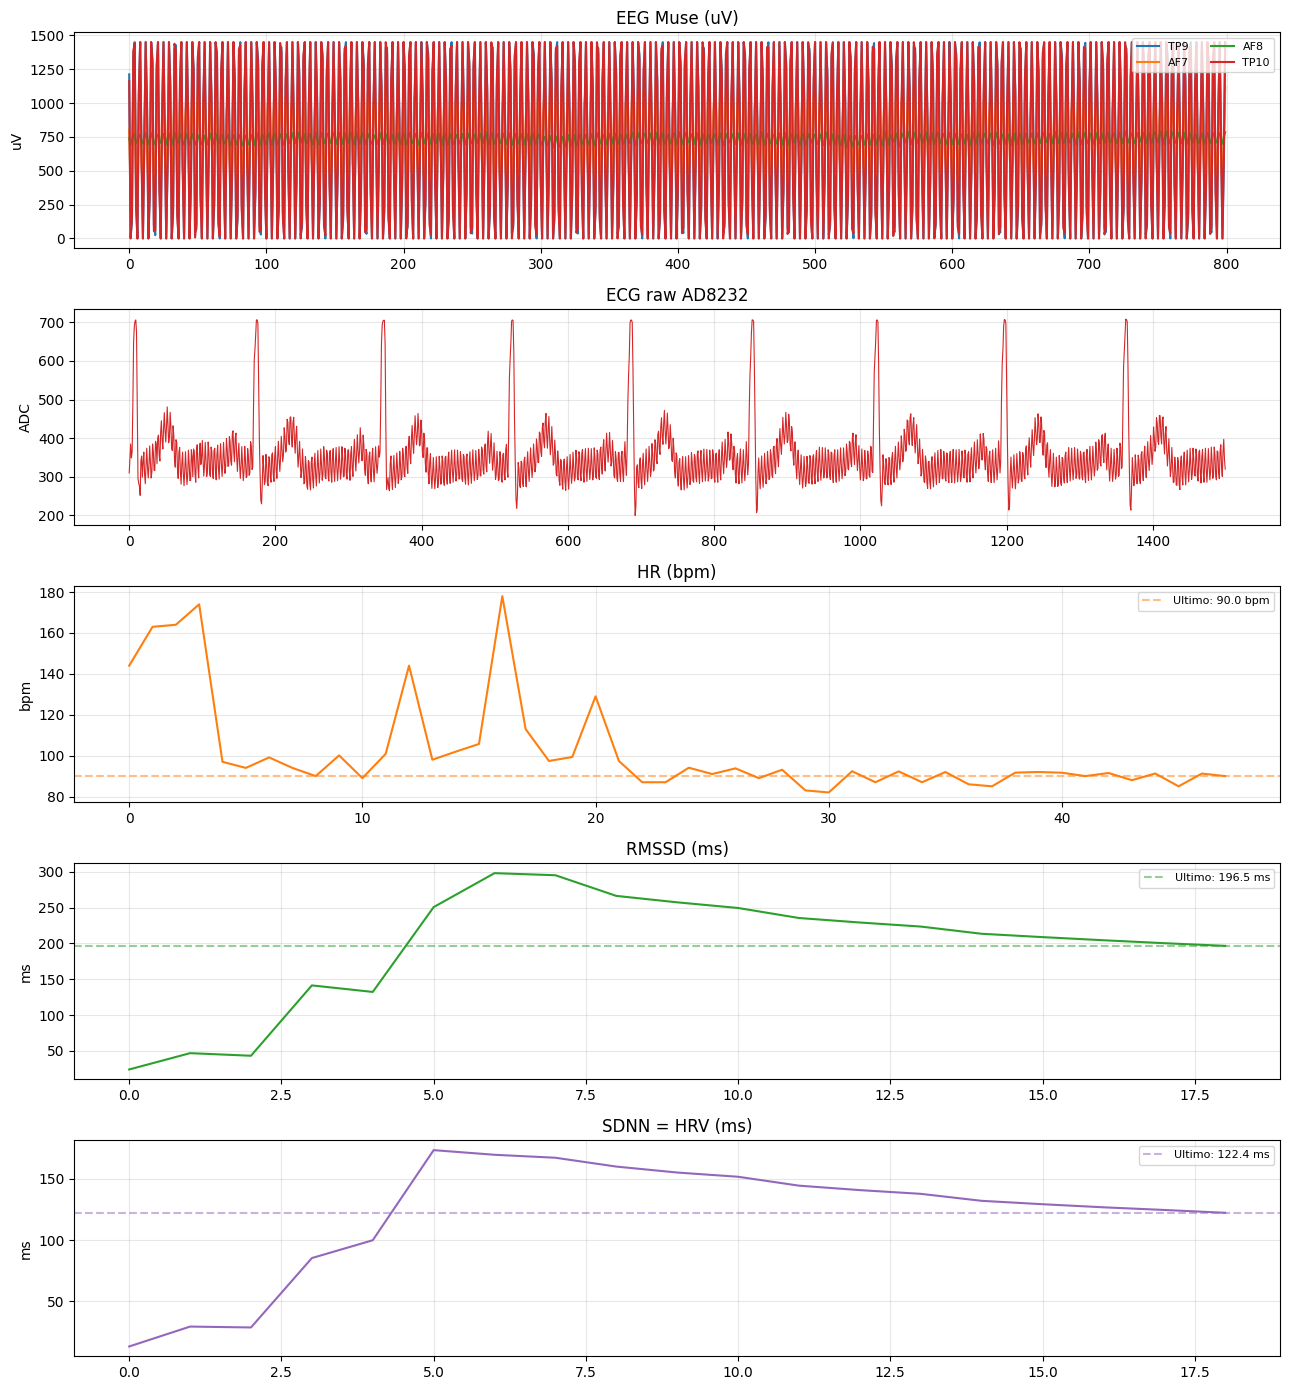

EEG muestras: 2174 | ECG muestras: 5125 | Picos R: 48 | HR: 90.0 bpm


CancelledError: 

In [43]:
async def live_signal_dashboard(refresh_sec=LIVE_REFRESH_SEC):
    if not live_buffers:
        raise RuntimeError("Sin buffers. Inicia la grabacion primero.")
    print("Dashboard en vivo. Interrumpe para detenerlo.")
    try:
        while True:
            clear_output(wait=True)
            fig, axes = plt.subplots(5, 1, figsize=(13, 14))

            eeg_labels  = ["TP9", "AF7", "AF8", "TP10"]
            eeg_buffers = live_buffers.get("muse_eeg", [])
            axes[0].set_title("EEG Muse (uV)")
            for i, buf in enumerate(eeg_buffers[:4]):
                vals = list(buf)
                if vals: axes[0].plot(vals[-800:], label=eeg_labels[i])
            axes[0].legend(loc="upper right", ncol=2, fontsize=8)
            axes[0].set_ylabel("uV"); axes[0].grid(alpha=0.3)

            ecg_raw = list(live_buffers.get("ecg_raw", []))
            axes[1].set_title("ECG raw AD8232")
            if ecg_raw: axes[1].plot(ecg_raw[-1500:], color="tab:red", lw=0.8)
            axes[1].set_ylabel("ADC"); axes[1].grid(alpha=0.3)

            hr_vals = list(live_buffers.get("ecg_hr", []))
            axes[2].set_title("HR (bpm)")
            if hr_vals:
                axes[2].plot(hr_vals, color="tab:orange")
                axes[2].axhline(hr_vals[-1], ls="--", color="tab:orange", alpha=0.5,
                                label=f"Ultimo: {hr_vals[-1]:.1f} bpm")
                axes[2].legend(fontsize=8)
            axes[2].set_ylabel("bpm"); axes[2].grid(alpha=0.3)

            rmssd_vals = list(live_buffers.get("ecg_rmssd", []))
            axes[3].set_title("RMSSD (ms)")
            if rmssd_vals:
                axes[3].plot(rmssd_vals, color="tab:green")
                axes[3].axhline(rmssd_vals[-1], ls="--", color="tab:green", alpha=0.5,
                                label=f"Ultimo: {rmssd_vals[-1]:.1f} ms")
                axes[3].legend(fontsize=8)
            axes[3].set_ylabel("ms"); axes[3].grid(alpha=0.3)

            sdnn_vals = list(live_buffers.get("ecg_sdnn", []))
            axes[4].set_title("SDNN = HRV (ms)")
            if sdnn_vals:
                axes[4].plot(sdnn_vals, color="tab:purple")
                axes[4].axhline(sdnn_vals[-1], ls="--", color="tab:purple", alpha=0.5,
                                label=f"Ultimo: {sdnn_vals[-1]:.1f} ms")
                axes[4].legend(fontsize=8)
            axes[4].set_ylabel("ms"); axes[4].grid(alpha=0.3)

            plt.tight_layout()
            display(fig)
            plt.close(fig)

            hr_now = f"{hr_vals[-1]:.1f} bpm" if hr_vals else "--"
            print(
                f"EEG muestras: {recording_stats.get('muse_eeg_samples', 0)} | "
                f"ECG muestras: {recording_stats.get('ecg_samples', 0)} | "
                f"Picos R: {recording_stats.get('ecg_r_peaks', 0)} | HR: {hr_now}"
            )
            await aio.sleep(refresh_sec)
    except KeyboardInterrupt:
        print("Dashboard detenido.")


await live_signal_dashboard()


## Analisis post-grabacion

Resumen de metricas ECG globales y graficas EEG.

In [3]:
# Lista todos los archivos disponibles
ecg_files = sorted(OUTPUT_DIR.glob("**/*_ad8232_ecg_*.csv"))
eeg_files = sorted(OUTPUT_DIR.glob("**/*_openmuse_eeg_*.csv"))

print("Archivos ECG disponibles:")
for i, f in enumerate(ecg_files):
    print(f"  [{i}] {f}")

print("\nArchivos EEG disponibles:")
for i, f in enumerate(eeg_files):
    print(f"  [{i}] {f}")

# Elige por índice
ECG_IDX = 0  # <-- cambia el número
EEG_IDX = 0  # <-- cambia el número

ECG_FILE = ecg_files[ECG_IDX]
EEG_FILE = eeg_files[EEG_IDX]

print(f"\nSeleccionado ECG: {ECG_FILE}")
print(f"Seleccionado EEG: {EEG_FILE}")

df_ecg = pd.read_csv(ECG_FILE)
df_eeg = pd.read_csv(EEG_FILE)

rr_valid = df_ecg["rr_ms"].dropna()
print("\n=== Metricas ECG globales ===")
print(f"  Muestras ECG      : {len(df_ecg)}")
print(f"  Picos R detectados: {len(rr_valid)}")
if len(rr_valid) >= 2:
    rr    = rr_valid.values
    hr    = round(60_000 / rr.mean(), 2)
    sdnn  = round(rr.std(), 2)
    rmssd = round(np.sqrt(np.mean(np.diff(rr)**2)), 2)
    print(f"  HR medio          : {hr} bpm")
    print(f"  SDNN (= HRV)      : {sdnn} ms")
    print(f"  RMSSD             : {rmssd} ms")


Archivos ECG disponibles:
  [0] recordings/subject_1/sub1_Moi_30_ad8232_ecg_20260408_103943.csv
  [1] recordings/subject_1/sub1_Moi_30_ad8232_ecg_20260408_103943_features.csv
  [2] recordings/subject_1/sub1_Moi_30_ad8232_ecg_20260408_103943_original.csv
  [3] recordings/subject_1/sub1_Moi_55_ad8232_ecg_20260408_105419.csv
  [4] recordings/subject_1/sub1_Moi_55_ad8232_ecg_20260408_105419_original.csv
  [5] recordings/subject_1/sub1_Moi_61_ad8232_ecg_20260408_102608.csv
  [6] recordings/subject_1/sub1_Moi_61_ad8232_ecg_20260408_102608_original.csv
  [7] recordings/subject_1/sub1_Moi_62_ad8232_ecg_20260408_104538.csv
  [8] recordings/subject_1/sub1_Moi_62_ad8232_ecg_20260408_104538_original.csv
  [9] recordings/subject_1/sub1_Moi_69_ad8232_ecg_20260408_103318.csv
  [10] recordings/subject_1/sub1_Moi_69_ad8232_ecg_20260408_103318_original.csv
  [11] recordings/subject_10/sub10_Juan_30_ad8232_ecg_20260411_150959.csv
  [12] recordings/subject_10/sub10_Juan_30_ad8232_ecg_20260411_150959_origi

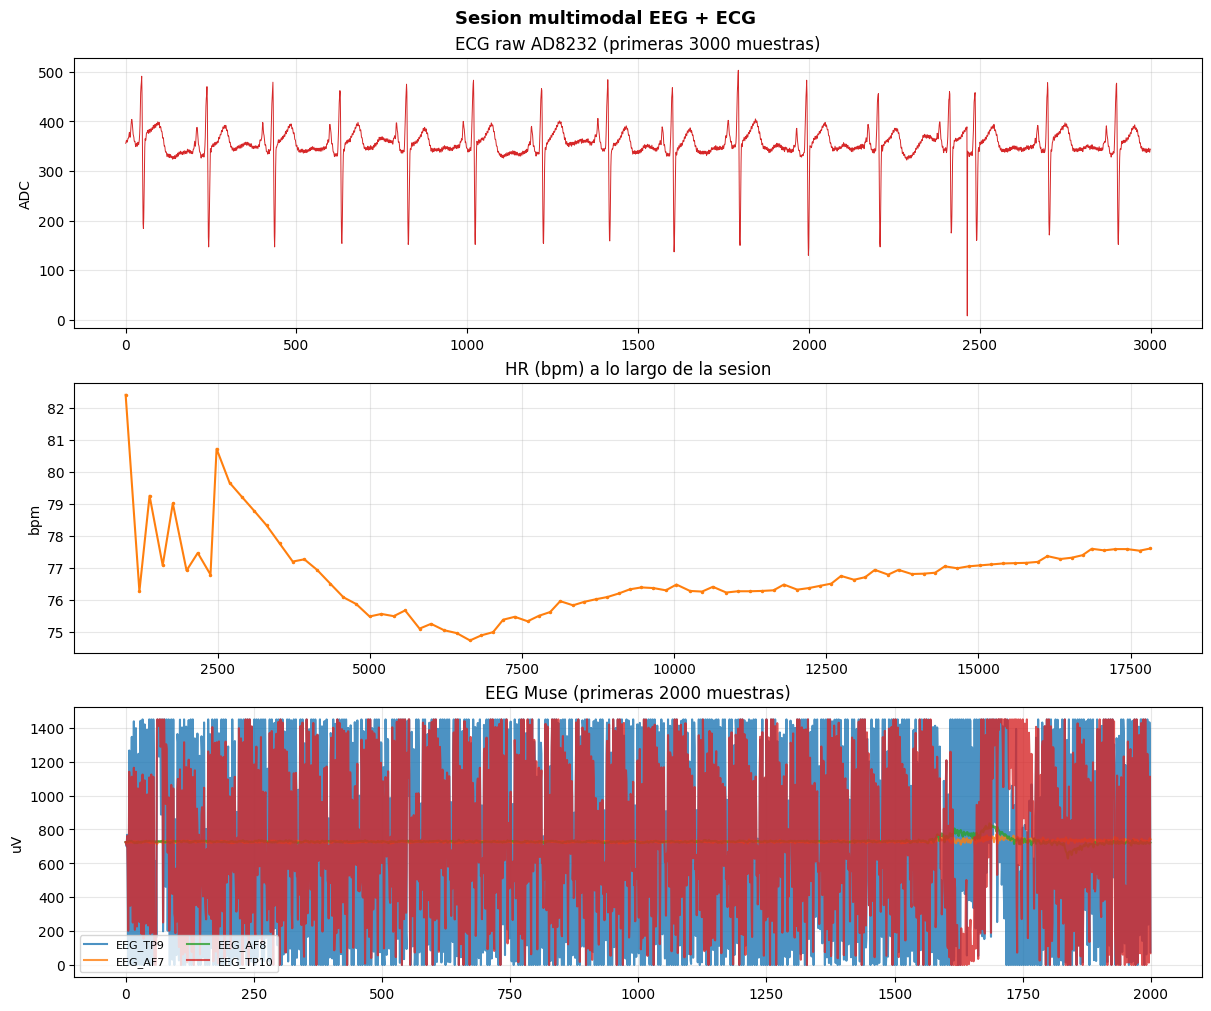

In [7]:
fig, axs = plt.subplots(3, 1, figsize=(12, 10), constrained_layout=True)

axs[0].plot(df_ecg["ecg_raw"].values[:3000], color="tab:red", lw=0.7)
axs[0].set_title("ECG raw AD8232 (primeras 3000 muestras)")
axs[0].set_ylabel("ADC"); axs[0].grid(alpha=0.3)

hr_series = df_ecg["hr_bpm"].dropna()
axs[1].plot(hr_series.index, hr_series.values, color="tab:orange", marker=".", ms=3)
axs[1].set_title("HR (bpm) a lo largo de la sesion")
axs[1].set_ylabel("bpm"); axs[1].grid(alpha=0.3)

eeg_ch = [c for c in df_eeg.columns if c.startswith("EEG")][:4]
for ch in eeg_ch:
    axs[2].plot(df_eeg[ch].values[:2000], label=ch, alpha=0.8)
axs[2].set_title("EEG Muse (primeras 2000 muestras)")
axs[2].set_ylabel("uV"); axs[2].legend(ncol=2, fontsize=8); axs[2].grid(alpha=0.3)

plt.suptitle("Sesion multimodal EEG + ECG", fontsize=13, fontweight="bold")
plt.show()


## Cerrar puerto serial

In [97]:
if recording_tasks and any(not t.done() for t in recording_tasks.values()):
    raise RuntimeError("Detén la grabacion antes de cerrar el puerto.")
if "ser" in globals() and ser is not None and hasattr(ser, "is_open") and ser.is_open:
    ser.close()
    print("Puerto serial cerrado.")
else:
    print("Puerto ya cerrado o no inicializado.")


Puerto serial cerrado.


## Enriquecimiento de CSVs de ECG

Los archivos grabados contienen `ecg_raw` pero las columnas `rr_ms`, `hr_bpm`,
`hrv_ms`, `rmssd_ms` y `sdnn_ms` quedan vacías porque el worker solo las llena
cuando detecta un pico R en tiempo real (detección online, muestra a muestra).

### Por qué recalcular offline

La detección online tiene dos limitaciones: (1) no puede aplicar filtros bidireccionales
(`filtfilt`) porque no tiene acceso al futuro de la señal, y (2) el threshold se
calibra solo sobre una ventana corta, lo que lo hace sensible a ruido transitorio.
El recálculo offline sobre la señal completa filtrada produce intervalos RR más precisos,
que a su vez mejoran la calidad de las features HRV en el dataset definitivo.

### Decisiones de implementación

**Threshold adaptativo:** se prueban tres factores en orden descendente (0.8, 0.5, 0.3
× std) y se acepta el primero que produce intervalos RR fisiológicamente razonables
(333–1500 ms, equivalente a 40–180 bpm). Esto resuelve el problema de señales de bajo
contraste (60–150 ADC) donde el threshold estándar de 0.8 × std queda por encima de
todos los picos.

**Backup automático:** antes de sobreescribir se genera `_original.csv` la primera vez,
garantizando que siempre se puede volver a los datos crudos si el recálculo produce
resultados inesperados.

**Ventana deslizante de HRV:** RMSSD y SDNN se calculan sobre los últimos 30 intervalos
RR (buffer circular) en lugar de sobre todos los intervalos acumulados, para capturar
la variabilidad local en lugar de la global de la sesión.


In [4]:
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.signal import butter, filtfilt, iirnotch, medfilt, find_peaks
from collections import deque
import warnings
warnings.filterwarnings('ignore')

OUTPUT_DIR = Path('recordings')
ECG_FS     = 250  # Hz — ajusta si es diferente

# ── Filtro ECG (idéntico al del pipeline) ────────────────────
def _interp_nans(sig):
    nans = np.isnan(sig)
    if nans.any():
        idx = np.arange(len(sig))
        sig[nans] = np.interp(idx[nans], idx[~nans], sig[~nans])
    return sig

def _filter_ecg(sig, fs):
    sig = _interp_nans(sig.copy().astype(float))
    k   = max(3, int(0.2 * fs)); k = k if k % 2 == 1 else k + 1
    sig = sig - medfilt(sig, kernel_size=k)
    nyq = fs / 2
    b, a = butter(4, [0.5/nyq, 40/nyq], btype='band')
    sig  = filtfilt(b, a, sig)
    b, a = iirnotch(60 / (fs/2), 30)
    return filtfilt(b, a, sig)

# ── Métricas acumuladas ───────────────────────────────────────
def _compute_rolling_hrv(rr_buffer):
    """Calcula RMSSD y SDNN sobre los últimos intervalos RR disponibles."""
    rr = np.array(rr_buffer)
    if len(rr) < 2:
        return np.nan, np.nan
    sdnn  = float(rr.std())
    rmssd = float(np.sqrt(np.mean(np.diff(rr) ** 2)))
    return rmssd, sdnn

# ── Función principal ─────────────────────────────────────────
def enrich_ecg_csv(csv_path, fs=ECG_FS, rr_buffer_size=30, backup=True):
    """
    Lee un CSV de ECG, recalcula rr_ms / hr_bpm / hrv_ms / rmssd_ms / sdnn_ms
    sobre la señal filtrada y sobreescribe el archivo.

    Parámetros
    ----------
    csv_path     : Path al archivo ECG
    fs           : frecuencia de muestreo del Arduino (Hz)
    rr_buffer_size : ventana deslizante de intervalos RR para calcular HRV
    backup       : si True, guarda una copia _original.csv la primera vez
    """
    csv_path = Path(csv_path)
    backup_path = csv_path.with_stem(csv_path.stem + '_original')

    # Backup de seguridad (solo si no existe ya)
    if backup and not backup_path.exists():
        import shutil
        shutil.copy(csv_path, backup_path)

    df = pd.read_csv(csv_path)

    if 'ecg_raw' not in df.columns:
        return 'SKIP — sin columna ecg_raw'

    # Longitud mínima: filtfilt necesita al menos padlen+1 muestras.
    # Butter orden 4 genera padlen ~27; usamos 100 como margen seguro.
    MIN_SAMPLES = 100
    if len(df) < MIN_SAMPLES:
        return f'SKIP — grabacion muy corta ({len(df)} muestras, minimo {MIN_SAMPLES})'

    # Elimina filas donde ecg_raw es NaN antes de filtrar
    df = df.dropna(subset=['ecg_raw']).reset_index(drop=True)
    if len(df) < MIN_SAMPLES:
        return f'SKIP — demasiados NaN en ecg_raw ({len(df)} muestras utiles)'

    # Limpia columnas que se van a recalcular
    for col in ['rr_ms', 'hr_bpm', 'hrv_ms', 'rmssd_ms', 'sdnn_ms']:
        df[col] = np.nan

    # Filtra la señal
    ecg_raw = df['ecg_raw'].values.astype(float)
    ecg_filt = _filter_ecg(ecg_raw, fs)

    # Detecta picos R sobre la señal completa
    m, s = ecg_filt.mean(), ecg_filt.std()
    if s == 0:
        return 'SKIP — señal plana'

    # Threshold adaptativo: prueba 0.8*std primero; si no encuentra picos
    # suficientes (señal de bajo contraste como 60-150 ADC), baja a 0.3*std.
    # Esto cubre grabaciones con señal débil sin perder precisión en señales fuertes.
    for threshold_factor in [0.8, 0.5, 0.3]:
        peaks, _ = find_peaks(
            ecg_filt,
            height   = m + threshold_factor * s,
            distance = int(fs * 0.4)   # mínimo 400 ms entre picos
        )
        # Verifica que la HR resultante sea fisiológicamente razonable (40-180 bpm)
        if len(peaks) >= 2:
            rr_check = np.diff(peaks) / fs * 1000
            rr_valid = rr_check[(rr_check > 333) & (rr_check < 1500)]  # 40-180 bpm
            if len(rr_valid) >= 2:
                break  # threshold encontrado

    if len(peaks) < 2:
        return 'SKIP — menos de 2 picos R detectados'

    # Escribe métricas en las filas de cada pico R
    rr_buffer = deque(maxlen=rr_buffer_size)
    last_peak_idx = None

    for peak_idx in peaks:
        if last_peak_idx is not None:
            rr_ms = (peak_idx - last_peak_idx) / fs * 1000.0

            # Filtro fisiológico: solo RR entre 300 ms y 1500 ms
            if 300 < rr_ms < 1500:
                rr_buffer.append(rr_ms)
                hr_bpm = 60_000 / rr_ms
                rmssd, sdnn = _compute_rolling_hrv(rr_buffer)

                df.loc[peak_idx, 'rr_ms']    = round(rr_ms, 3)
                df.loc[peak_idx, 'hr_bpm']   = round(hr_bpm, 2)
                df.loc[peak_idx, 'hrv_ms']   = round(sdnn, 3) if not np.isnan(sdnn) else np.nan
                df.loc[peak_idx, 'rmssd_ms'] = round(rmssd, 3) if not np.isnan(rmssd) else np.nan
                df.loc[peak_idx, 'sdnn_ms']  = round(sdnn, 3) if not np.isnan(sdnn) else np.nan

        last_peak_idx = peak_idx

    df.to_csv(csv_path, index=False)

    n_peaks   = len(peaks)
    n_valid   = df['rr_ms'].notna().sum()
    hr_mean   = df['hr_bpm'].dropna().mean()
    return (f'{n_peaks} picos R  |  {n_valid} intervalos válidos  |  '
            f'HR media {hr_mean:.1f} bpm')


# ── Procesa todos los CSVs ECG ────────────────────────────────
ecg_files = sorted(OUTPUT_DIR.glob('**/*_ad8232_ecg_*.csv'))
# Excluye archivos de backup
ecg_files = [f for f in ecg_files if '_original' not in f.stem]

print(f'Archivos ECG encontrados: {len(ecg_files)}')
print()

resultados = []
for ecg_path in ecg_files:
    resultado = enrich_ecg_csv(ecg_path, fs=ECG_FS)
    status    = 'OK  ' if resultado.startswith('SKIP') is False else 'SKIP'
    short     = ecg_path.parent.name + '/' + ecg_path.name
    print(f'{status}  {short}')
    print(f'      {resultado}')
    resultados.append({'archivo': short, 'resultado': resultado})

print(f'\nFinalizado — {sum(1 for r in resultados if not r["resultado"].startswith("SKIP"))} '
      f'archivos enriquecidos, '
      f'{sum(1 for r in resultados if r["resultado"].startswith("SKIP"))} omitidos.')


Archivos ECG encontrados: 52

OK    subject_1/sub1_Moi_30_ad8232_ecg_20260408_103943.csv
      220 picos R  |  219 intervalos válidos  |  HR media 58.7 bpm
SKIP  subject_1/sub1_Moi_30_ad8232_ecg_20260408_103943_features.csv
      SKIP — sin columna ecg_raw
OK    subject_1/sub1_Moi_55_ad8232_ecg_20260408_105419.csv
      252 picos R  |  251 intervalos válidos  |  HR media 57.9 bpm
OK    subject_1/sub1_Moi_61_ad8232_ecg_20260408_102608.csv
      205 picos R  |  204 intervalos válidos  |  HR media 57.9 bpm
OK    subject_1/sub1_Moi_62_ad8232_ecg_20260408_104538.csv
      474 picos R  |  473 intervalos válidos  |  HR media 81.7 bpm
OK    subject_1/sub1_Moi_69_ad8232_ecg_20260408_103318.csv
      232 picos R  |  231 intervalos válidos  |  HR media 58.5 bpm
OK    subject_10/sub10_Juan_30_ad8232_ecg_20260411_150959.csv
      333 picos R  |  332 intervalos válidos  |  HR media 82.5 bpm
OK    subject_10/sub10_Juan_55_ad8232_ecg_20260411_150317.csv
      380 picos R  |  379 intervalos válidos  | 

### Verificación del enriquecimiento

Se carga un archivo de muestra para confirmar que las columnas quedaron correctamente
pobladas y que los valores de HR son fisiológicamente razonables (40–200 bpm).

In [5]:
# Muestra el primer archivo procesado como verificación
ecg_sample = [f for f in sorted(OUTPUT_DIR.glob('**/*_ad8232_ecg_*.csv'))
              if '_original' not in f.stem][0]

df_check = pd.read_csv(ecg_sample)

print(f'Archivo: {ecg_sample.name}')
print(f'Filas totales       : {len(df_check)}')
print(f'Picos R (rr_ms)     : {df_check["rr_ms"].notna().sum()}')
print()
print('Estadísticas de las columnas calculadas:')
print(df_check[['rr_ms','hr_bpm','rmssd_ms','sdnn_ms']].describe().round(2))
print()
print('Primeras filas con pico R detectado:')
print(df_check[df_check['rr_ms'].notna()]
      [['host_time_utc','ecg_raw','rr_ms','hr_bpm','rmssd_ms','sdnn_ms']]
      .head(8).to_string(index=False))

# Alerta si hay valores fuera de rango fisiológico
hr_vals = df_check['hr_bpm'].dropna()
fuera   = hr_vals[(hr_vals < 40) | (hr_vals > 200)]
if len(fuera) > 0:
    print(f'\nATENCIÓN: {len(fuera)} valores de HR fuera de rango (40–200 bpm):')
    print(fuera.values)
else:
    print(f'\nTodos los valores de HR dentro del rango fisiológico (40–200 bpm).')


Archivo: sub1_Moi_30_ad8232_ecg_20260408_103943.csv
Filas totales       : 56361
Picos R (rr_ms)     : 219

Estadísticas de las columnas calculadas:
         rr_ms  hr_bpm  rmssd_ms  sdnn_ms
count   219.00  219.00    218.00   218.00
mean   1023.71   58.72     46.30    39.53
std      42.99    2.72     16.59    14.22
min     772.00   54.55     29.35    16.00
25%    1000.00   57.03     37.08    29.99
50%    1028.00   58.37     39.49    33.11
75%    1052.00   60.00     50.83    54.54
max    1100.00   77.72    115.92    85.71

Primeras filas con pico R detectado:
              host_time_utc  ecg_raw  rr_ms  hr_bpm  rmssd_ms  sdnn_ms
2026-04-08T17:39:43.786421Z    706.0 1004.0   59.76       NaN      NaN
2026-04-08T17:39:43.815183Z    708.0  972.0   61.73    32.000   16.000
2026-04-08T17:39:43.850495Z    707.0 1012.0   59.29    36.222   17.282
2026-04-08T17:39:43.888941Z    707.0 1056.0   56.82    38.987   29.983
2026-04-08T17:39:43.923812Z    707.0 1028.0   58.37    36.551   27.667
2026-04-08

# 2. Sincronización de señales

El EEG (Muse S, ~256 Hz vía BLE) y el ECG (AD8232, 250 Hz vía serial) se graban
de forma independiente, cada uno con su propio reloj interno. Para analizarlos juntos
en el mismo eje de tiempo es necesario alinearlos.

### Decisiones de diseño

**Timestamp del host como referencia:** ambos workers registran `time.time_ns()` del
sistema operativo en el momento de recibir cada paquete. Este es el único reloj
compartido disponible sin hardware adicional de sincronización.

**Remuestreo a cuadrícula común de 100 Hz:** se elige 100 Hz como frecuencia de la
cuadrícula común porque: (a) es suficiente para todas las bandas de interés del EEG
(hasta 45 Hz, Nyquist requiere 90 Hz) y del ECG (hasta 40 Hz), (b) reduce el volumen
de datos sin pérdida de información, y (c) simplifica el ventaneo al tener ambas
señales en el mismo índice.

**Interpolación lineal:** se usa `numpy.interp` para remuestrear. Para señales
fisiológicas suaves como EEG y ECG filtrado, la interpolación lineal es suficiente
y más estable que la cúbica en presencia de artefactos.

**t=0 compartido:** el offset temporal se fija en el timestamp más temprano entre
ambas señales, garantizando que t=0 coincide con el inicio real de la grabación.


## Carga de archivos para sincronización

In [52]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

OUTPUT_DIR = Path('recordings')

ecg_files = sorted(OUTPUT_DIR.glob('**/*_ad8232_ecg_*.csv'))
eeg_files = sorted(OUTPUT_DIR.glob('**/*_openmuse_eeg_*.csv'))

print('Archivos ECG disponibles:')
for i, f in enumerate(ecg_files):
    print(f'  [{i}] {f}')
print('\nArchivos EEG disponibles:')
for i, f in enumerate(eeg_files):
    print(f'  [{i}] {f}')

ECG_IDX = 0  # <-- cambia el número
EEG_IDX = 0

ECG_FILE = ecg_files[ECG_IDX]
EEG_FILE = eeg_files[EEG_IDX]

df_ecg = pd.read_csv(ECG_FILE)
df_eeg = pd.read_csv(EEG_FILE)

eeg_cols = [c for c in df_eeg.columns if c.startswith('EEG')][:4]
CH_NAMES = ['TP9', 'AF7', 'AF8', 'TP10']

print(f'\nECG: {len(df_ecg)} muestras')
print(f'EEG: {len(df_eeg)} muestras — canales: {eeg_cols}')

Archivos ECG disponibles:
  [0] recordings/subject_1/sub1_Moi_30_ad8232_ecg_20260408_103943.csv
  [1] recordings/subject_1/sub1_Moi_30_ad8232_ecg_20260408_103943_features.csv
  [2] recordings/subject_1/sub1_Moi_30_ad8232_ecg_20260408_103943_features_original.csv
  [3] recordings/subject_1/sub1_Moi_30_ad8232_ecg_20260408_103943_original.csv
  [4] recordings/subject_1/sub1_Moi_55_ad8232_ecg_20260408_105419.csv
  [5] recordings/subject_1/sub1_Moi_55_ad8232_ecg_20260408_105419_original.csv
  [6] recordings/subject_1/sub1_Moi_61_ad8232_ecg_20260408_102608.csv
  [7] recordings/subject_1/sub1_Moi_61_ad8232_ecg_20260408_102608_original.csv
  [8] recordings/subject_1/sub1_Moi_62_ad8232_ecg_20260408_104538.csv
  [9] recordings/subject_1/sub1_Moi_62_ad8232_ecg_20260408_104538_original.csv
  [10] recordings/subject_1/sub1_Moi_69_ad8232_ecg_20260408_103318.csv
  [11] recordings/subject_1/sub1_Moi_69_ad8232_ecg_20260408_103318_original.csv
  [12] recordings/subject_10/sub10_Juan_30_ad8232_ecg_202604

## Conversión de timestamps y remuestreo

Se toma el timestamp más temprano entre ambas señales como `t=0` para que los ejes de tiempo 
sean comparables. Luego se interpola cada señal a una cuadrícula uniforme de 10 ms (100 Hz), 
frecuencia suficiente para todas las bandas de interés del EEG y el ECG.

In [53]:
ECG_FS = 250
EEG_FS = 256
SYNC_FS = 100  # Hz de la cuadrícula común

# Tiempo en segundos desde el inicio de cada señal
ecg_t = df_ecg['host_time_ns'].values / 1e9
eeg_t = df_eeg['host_time_ns'].values / 1e9

# t=0 = inicio de la grabación (el más temprano entre ambas)
t0 = min(ecg_t[0], eeg_t[0])
ecg_t = ecg_t - t0
eeg_t = eeg_t - t0

# Duración útil = la más corta de las dos señales
t_end = min(ecg_t[-1], eeg_t[-1])
t_common = np.arange(0, t_end, 1.0 / SYNC_FS)

# Remuestreo ECG
ecg_raw_vals = df_ecg['ecg_raw'].values.astype(float)
# Interpola NaNs antes de remuestrear
nan_mask = np.isnan(ecg_raw_vals)
if nan_mask.any():
    ecg_raw_vals[nan_mask] = np.interp(np.where(nan_mask)[0],
                                        np.where(~nan_mask)[0],
                                        ecg_raw_vals[~nan_mask])
ecg_sync = np.interp(t_common, ecg_t, ecg_raw_vals)

# Remuestreo EEG (canal por canal)
eeg_sync = {}
for col, name in zip(eeg_cols, CH_NAMES):
    sig = df_eeg[col].values.astype(float)
    nan_m = np.isnan(sig)
    if nan_m.any():
        sig[nan_m] = np.interp(np.where(nan_m)[0], np.where(~nan_m)[0], sig[~nan_m])
    eeg_sync[name] = np.interp(t_common, eeg_t, sig)

print(f'Duración sincronizada : {t_end:.1f} s')
print(f'Muestras en cuadrícula: {len(t_common)} @ {SYNC_FS} Hz')

Duración sincronizada : 216.1 s
Muestras en cuadrícula: 21615 @ 100 Hz


## Verificación visual del alineamiento

Se grafican los primeros 30 segundos de ECG y EEG en el mismo eje de tiempo para confirmar 
que la sincronización es correcta.

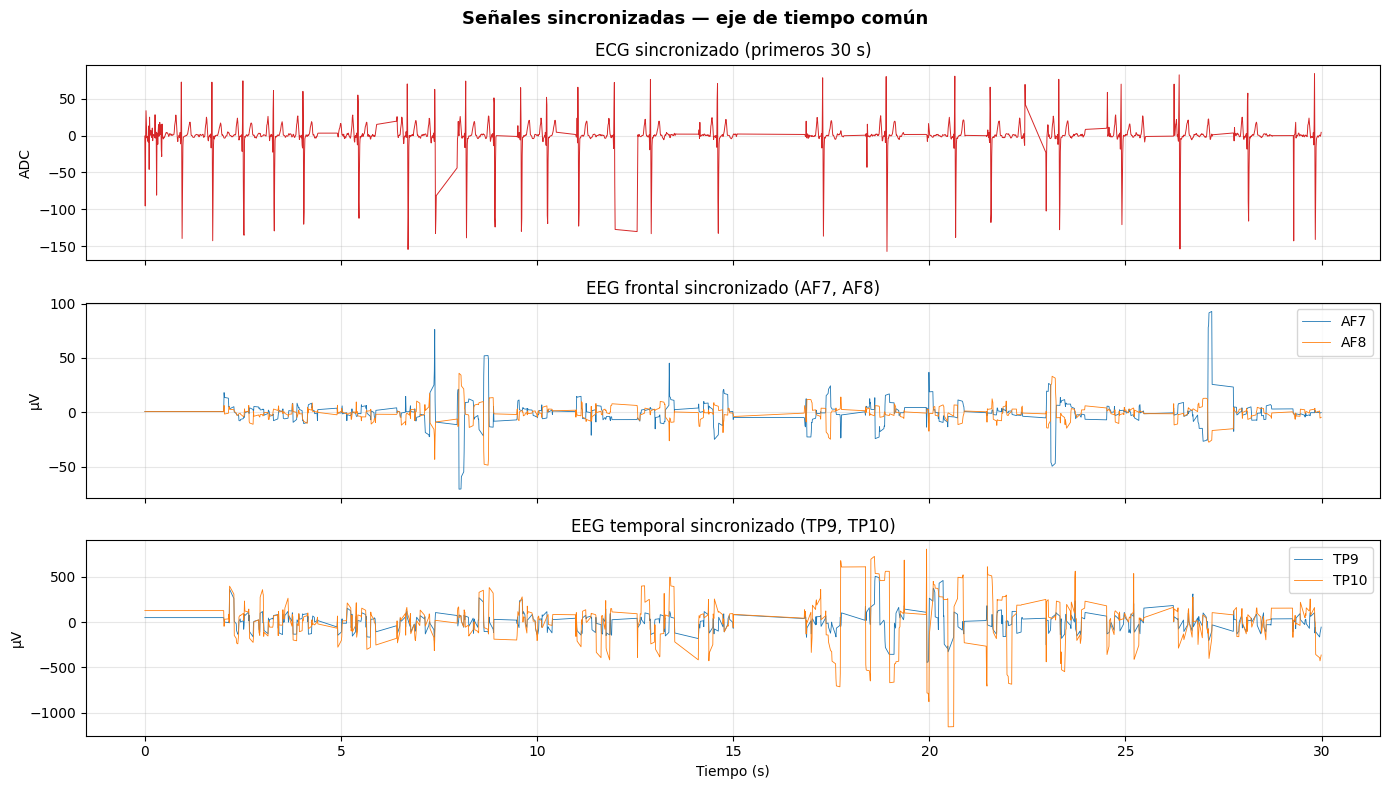

In [129]:
seg = slice(0, SYNC_FS * 30)
t_plot = t_common[seg]

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

axes[0].plot(t_plot, ecg_sync[seg], color='tab:red', lw=0.7)
axes[0].set_title('ECG sincronizado (primeros 30 s)')
axes[0].set_ylabel('ADC'); axes[0].grid(alpha=0.3)

for name in ['AF7', 'AF8']:
    axes[1].plot(t_plot, eeg_sync[name][seg], lw=0.6, label=name)
axes[1].set_title('EEG frontal sincronizado (AF7, AF8)')
axes[1].set_ylabel('µV'); axes[1].legend(); axes[1].grid(alpha=0.3)

for name in ['TP9', 'TP10']:
    axes[2].plot(t_plot, eeg_sync[name][seg], lw=0.6, label=name)
axes[2].set_title('EEG temporal sincronizado (TP9, TP10)')
axes[2].set_ylabel('µV'); axes[2].set_xlabel('Tiempo (s)')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.suptitle('Señales sincronizadas — eje de tiempo común', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('report/MDPI_Article_Template/figures/senales_sincronizadas.png', dpi=150, bbox_inches='tight')
plt.show()

# 3. Preprocesamiento de señales

Antes de extraer features es necesario limpiar las señales crudas. Las señales
biológicas capturadas con hardware de bajo costo contienen múltiples fuentes de ruido
que, si no se eliminan, producen features incorrectas y degradan el desempeño del
clasificador. Esta sección sigue el pipeline estándar de los datasets DEAP y MAHNOB-HCI.


## 1. Visualización de señales crudas

El primer paso siempre es visualizar los datos sin ningún procesamiento. Esto permite identificar 
visualmente qué tipo de artefactos están presentes antes de decidir qué filtros aplicar.

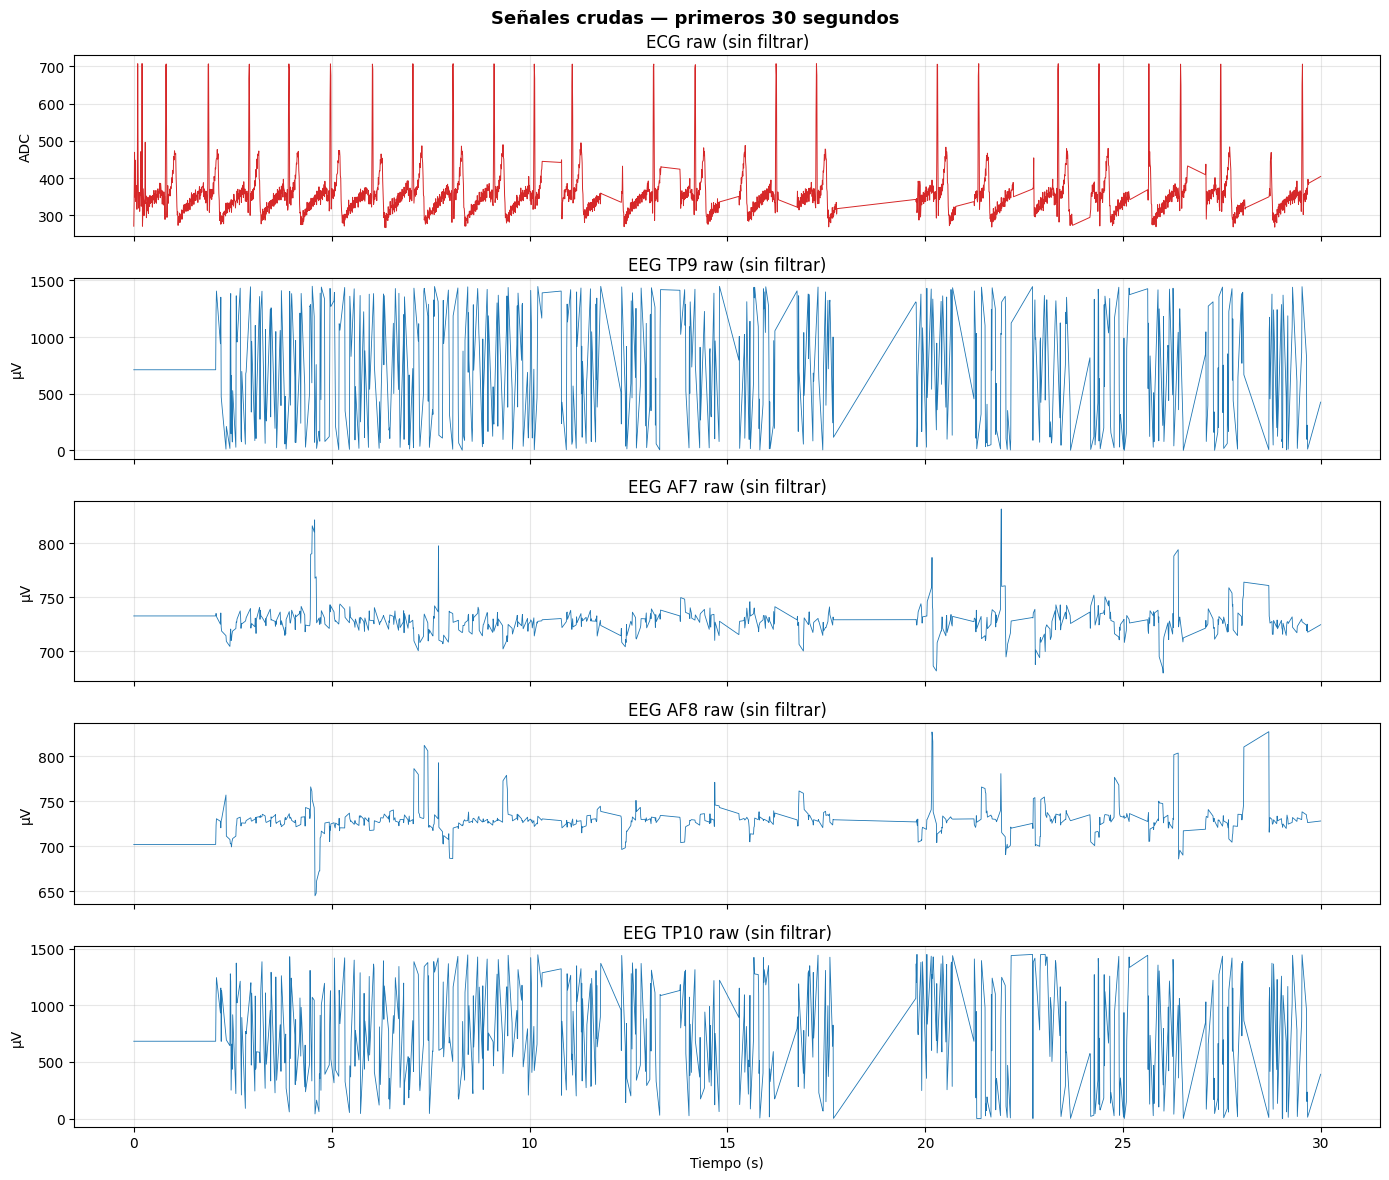

In [55]:
fig, axes = plt.subplots(5, 1, figsize=(14, 12), sharex=True)

seg30 = slice(0, SYNC_FS * 30)
t30 = t_common[seg30]

axes[0].set_title('ECG raw (sin filtrar)')
axes[0].plot(t30, ecg_sync[seg30], color='tab:red', lw=0.7)
axes[0].set_ylabel('ADC'); axes[0].grid(alpha=0.3)

for i, name in enumerate(CH_NAMES):
    axes[i+1].set_title(f'EEG {name} raw (sin filtrar)')
    axes[i+1].plot(t30, eeg_sync[name][seg30], lw=0.6)
    axes[i+1].set_ylabel('µV'); axes[i+1].grid(alpha=0.3)

axes[-1].set_xlabel('Tiempo (s)')
plt.suptitle('Señales crudas — primeros 30 segundos', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Filtros ECG

### Decisiones de diseño

**Orden del pipeline:** primero baseline, luego bandpass, luego notch. Si se aplica
el bandpass antes del filtro de mediana, la deriva de línea base se amplifica antes
de que pueda eliminarse.

**Filtro de mediana para baseline:** se prefiere sobre un highpass agresivo porque
la mediana es insensible a los picos R (outliers en amplitud). Un highpass simple
distorsiona la morfología del QRS, lo que afecta la detección de picos R.

**Butterworth orden 4, 0.5–40 Hz:** el rango 0.5–40 Hz cubre todo el espectro clínico
útil del ECG. El orden 4 ofrece buen rechazo fuera de banda sin distorsión de fase
excesiva. Se usa `filtfilt` (zero-phase) para no introducir desfase temporal, lo cual
es crítico para la detección precisa de picos R.

**Notch a 60 Hz:** México usa red eléctrica a 60 Hz. Se elige Q=30 (ancho de banda
de ~2 Hz) para eliminar la interferencia sin afectar las frecuencias adyacentes.

**Umbrales de rechazo:** amplitud pico a pico > 900 ADC indica saturación del
conversor del AD8232. Std < 5 ADC indica electrodo desconectado (señal plana).


In [56]:
from scipy.signal import butter, filtfilt, iirnotch, medfilt
from scipy.stats import kurtosis, skew

def ecg_remove_baseline(signal, fs, window_sec=0.2):
    kernel = int(window_sec * fs)
    kernel = kernel if kernel % 2 == 1 else kernel + 1
    return signal - medfilt(signal, kernel_size=kernel)

def ecg_bandpass(signal, fs, lowcut=0.5, highcut=40.0, order=4):
    nyq = fs / 2
    b, a = butter(order, [lowcut / nyq, highcut / nyq], btype='band')
    return filtfilt(b, a, signal)

def ecg_notch(signal, fs, freq=60.0, Q=30):
    b, a = iirnotch(freq / (fs / 2), Q)
    return filtfilt(b, a, signal)

def detect_bad_ecg_segment(signal, amp_threshold=900.0, flat_threshold=5.0):
    return (signal.max() - signal.min()) > amp_threshold or signal.std() < flat_threshold

def preprocess_ecg(signal, fs):
    nans = np.isnan(signal)
    if nans.any():
        idx = np.arange(len(signal))
        signal[nans] = np.interp(idx[nans], idx[~nans], signal[~nans])
    signal = ecg_remove_baseline(signal, fs)
    signal = ecg_bandpass(signal, fs)
    signal = ecg_notch(signal, fs)
    return signal

print('Filtros ECG definidos.')

Filtros ECG definidos.


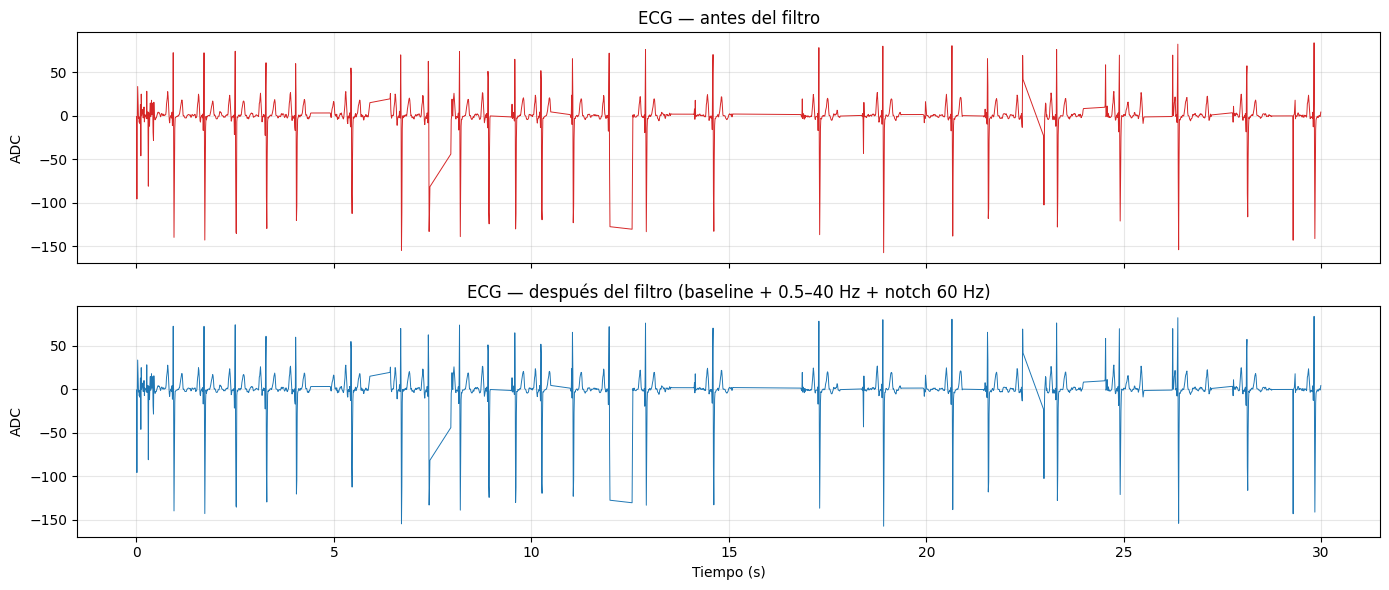

In [127]:
ecg_raw_orig = df_ecg['ecg_raw'].values.astype(float)
ecg_clean = preprocess_ecg(ecg_raw_orig.copy(), ECG_FS)

# Remuestrear la versión limpia a la cuadrícula común
ecg_clean_sync = np.interp(t_common, ecg_t, ecg_clean)

seg = slice(0, SYNC_FS * 30)
t_plot = t_common[seg]

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(t_plot, ecg_sync[seg], color='tab:red', lw=0.7)
axes[0].set_title('ECG — antes del filtro')
axes[0].set_ylabel('ADC'); axes[0].grid(alpha=0.3)

axes[1].plot(t_plot, ecg_clean_sync[seg], color='tab:blue', lw=0.7)
axes[1].set_title('ECG — después del filtro (baseline + 0.5–40 Hz + notch 60 Hz)')
axes[1].set_ylabel('ADC'); axes[1].set_xlabel('Tiempo (s)'); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('report/MDPI_Article_Template/figures/ecg_raw_vs_filtrado.png', dpi=150, bbox_inches='tight')
plt.show()

## Filtros EEG

### Decisiones de diseño

**Bandpass 1–45 Hz:** el límite inferior de 1 Hz (en lugar de 0.5 Hz del ECG) elimina
más agresivamente la deriva por movimiento de cabeza, que es el artefacto más frecuente
del Muse S. El límite superior de 45 Hz incluye la banda gamma completa.

**Umbrales adaptativos por sesión (percentil 99):** los umbrales fijos (150 µV de
amplitud, kurtosis > 5) rechazan demasiadas ventanas en sujetos con señal naturalmente
más amplia. El percentil 99 de la sesión calibra el umbral al rango real de cada
participante, eliminando solo los outliers genuinos sin descartar señal normal.

**Por qué kurtosis:** los artefactos EMG (contracción muscular) producen ráfagas de
energía concentradas en el tiempo — distribución leptocúrtica (kurtosis alta). El
ruido gaussiano tiene kurtosis ≈ 0. La combinación amplitud + kurtosis detecta tipos
de artefacto complementarios.

**Nota sobre ICA:** la técnica gold standard para separar artefactos de EOG y EMG es
Independent Component Analysis. Con solo 4 canales el Muse S no tiene suficiente
resolución espacial para aplicar ICA de forma confiable; el rechazo de ventanas es
la alternativa práctica estándar para sistemas de pocos canales.


In [58]:
def butter_bandpass(signal, fs, lowcut=1.0, highcut=45.0, order=4):
    nyq = fs / 2
    b, a = butter(order, [lowcut / nyq, highcut / nyq], btype='band')
    return filtfilt(b, a, signal)

def notch_filter(signal, fs, freq=60.0, Q=30):
    b, a = iirnotch(freq / (fs / 2), Q)
    return filtfilt(b, a, signal)

def detect_bad_eeg_segment(signal, amp_threshold=150.0, kurt_threshold=5.0):
    return (signal.max() - signal.min()) > amp_threshold or kurtosis(signal) > kurt_threshold

def preprocess_eeg_channel(signal, fs):
    nans = np.isnan(signal)
    if nans.any():
        idx = np.arange(len(signal))
        signal[nans] = np.interp(idx[nans], idx[~nans], signal[~nans])
    signal = butter_bandpass(signal, fs)
    signal = notch_filter(signal, fs)
    return signal

print('Filtros EEG definidos.')

Filtros EEG definidos.


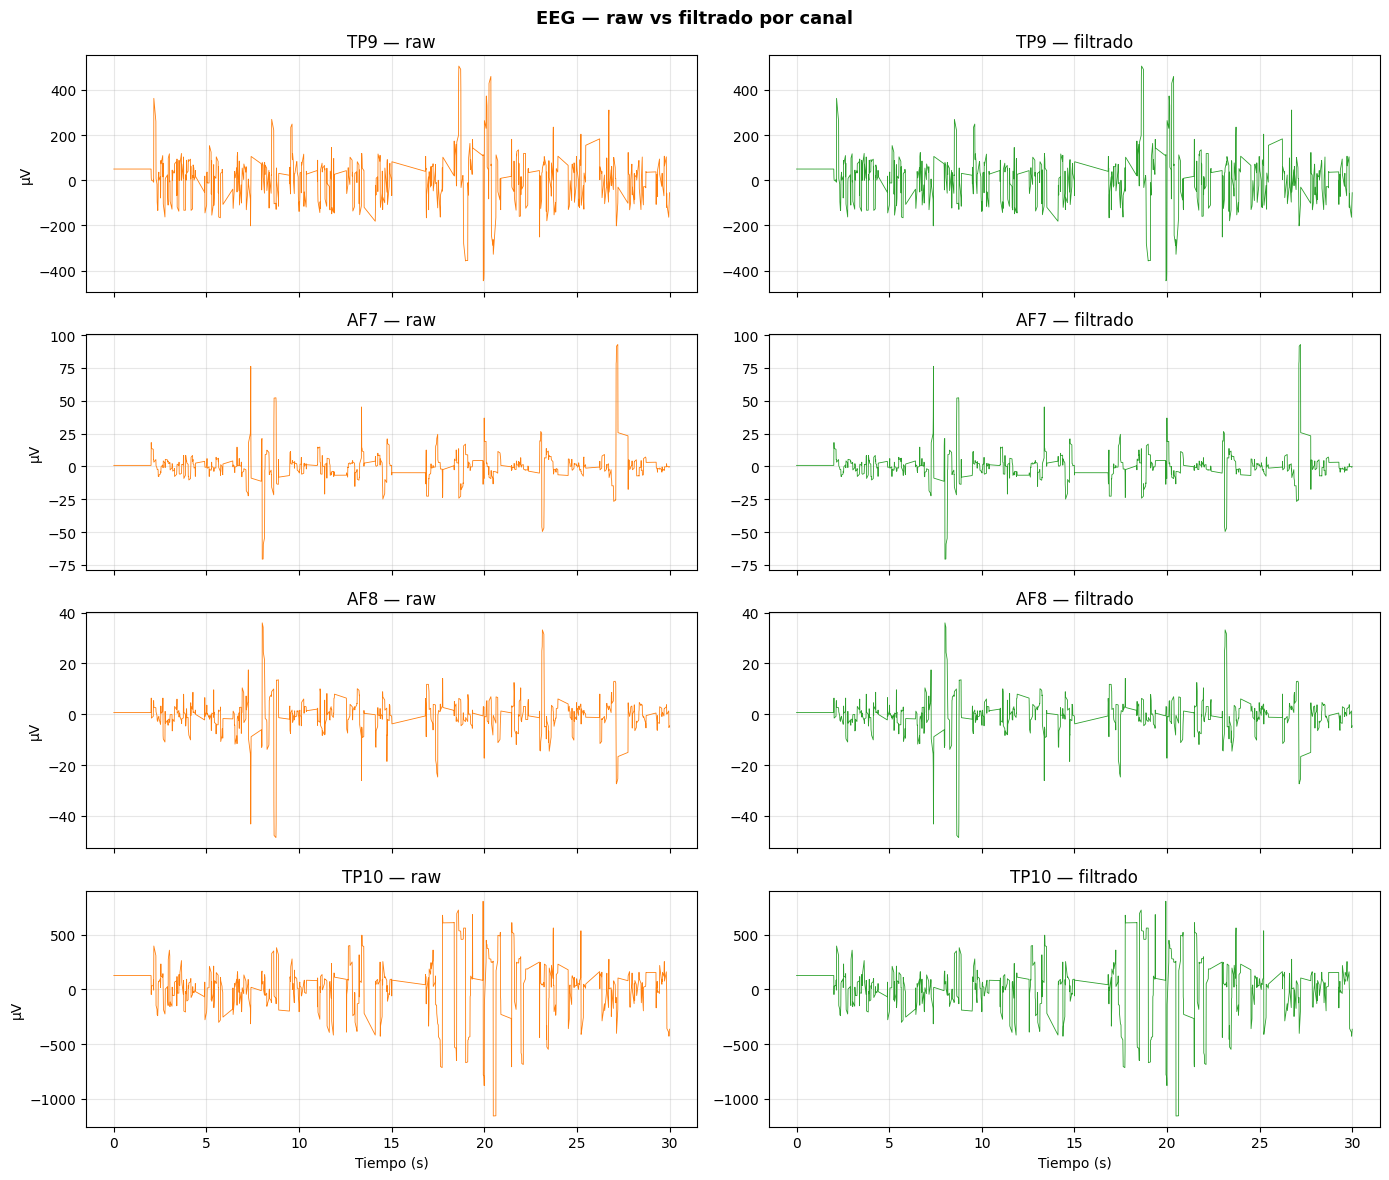

In [126]:
df_eeg_clean = df_eeg.copy()
eeg_clean_sync = {}

for col, name in zip(eeg_cols, CH_NAMES):
    sig = df_eeg_clean[col].values.astype(float)
    clean = preprocess_eeg_channel(sig.copy(), EEG_FS)
    df_eeg_clean[col] = clean
    eeg_clean_sync[name] = np.interp(t_common, eeg_t, clean)

fig, axes = plt.subplots(4, 2, figsize=(14, 12), sharex=True)
seg = slice(0, SYNC_FS * 30)
t_plot = t_common[seg]

for i, name in enumerate(CH_NAMES):
    axes[i][0].plot(t_plot, eeg_sync[name][seg], lw=0.6, color='tab:orange')
    axes[i][0].set_title(f'{name} — raw'); axes[i][0].set_ylabel('µV'); axes[i][0].grid(alpha=0.3)
    axes[i][1].plot(t_plot, eeg_clean_sync[name][seg], lw=0.6, color='tab:green')
    axes[i][1].set_title(f'{name} — filtrado'); axes[i][1].grid(alpha=0.3)

axes[-1][0].set_xlabel('Tiempo (s)')
axes[-1][1].set_xlabel('Tiempo (s)')
plt.suptitle('EEG — raw vs filtrado por canal', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('report/MDPI_Article_Template/figures/eeg_raw_vs_filtrado.png', dpi=150, bbox_inches='tight')
plt.show()

# 4. Exploración estadística de los datos

Antes de extraer features es importante entender la distribución y calidad de los
datos crudos. Esta sección diagnostica posibles problemas — valores anómalos, NaNs
excesivos, señal plana — que podrían propagarse silenciosamente al dataset final.

### Decisiones de diseño

**Por qué explorar antes de filtrar:** los filtros pueden enmascarar problemas en los
datos. Por ejemplo, una grabación con el electrodo parcialmente desprendido produce
una señal que pasa los filtros pero tiene distribución anómala. Detectarlo aquí evita
incluir esa sesión en el dataset.

**Detección de picos R sobre señal completa (no por ventana):** se detectan los picos
R sobre la señal completa de la sesión y luego se filtran los que caen en cada ventana.
Esto es más preciso que detectar picos ventana por ventana porque el threshold se
calibra con más contexto y no hay efecto de borde en los extremos de cada ventana.


In [60]:
print('=== Estadísticas ECG ===')
print(df_ecg[['ecg_raw', 'hr_bpm', 'rr_ms']].describe().round(2))
print(f'\nNaNs por columna:')
print(df_ecg[['ecg_raw', 'hr_bpm', 'rr_ms']].isna().sum())
print(f'\nDuración sesión ECG: {len(df_ecg)/ECG_FS:.1f} s')

print('\n=== Estadísticas EEG ===')
print(df_eeg[eeg_cols].describe().round(2))
print(f'\nNaNs por canal:')
print(df_eeg[eeg_cols].isna().sum())
print(f'\nDuración sesión EEG: {len(df_eeg)/EEG_FS:.1f} s')

=== Estadísticas ECG ===
        ecg_raw  hr_bpm    rr_ms
count  56361.00  219.00   219.00
mean     357.64   58.72  1023.71
std       67.55    2.72    42.99
min        1.00   54.55   772.00
25%      321.00   57.03  1000.00
50%      345.00   58.37  1028.00
75%      372.00   60.00  1052.00
max      710.00   77.72  1100.00

NaNs por columna:
ecg_raw        0
hr_bpm     56142
rr_ms      56142
dtype: int64

Duración sesión ECG: 225.4 s

=== Estadísticas EEG ===
        EEG_TP9   EEG_AF7   EEG_AF8  EEG_TP10
count  54976.00  54976.00  54976.00  54976.00
mean     722.57    728.51    728.72    723.13
std      570.52     15.96     17.22    549.11
min        0.00    605.38    619.01      0.00
25%       99.13    721.15    722.83    155.93
50%      721.50    727.79    728.50    717.83
75%     1343.46    734.16    733.63   1292.46
max     1450.00    879.22    869.75   1450.00

NaNs por canal:
EEG_TP9     0
EEG_AF7     0
EEG_AF8     0
EEG_TP10    0
dtype: int64

Duración sesión EEG: 214.8 s


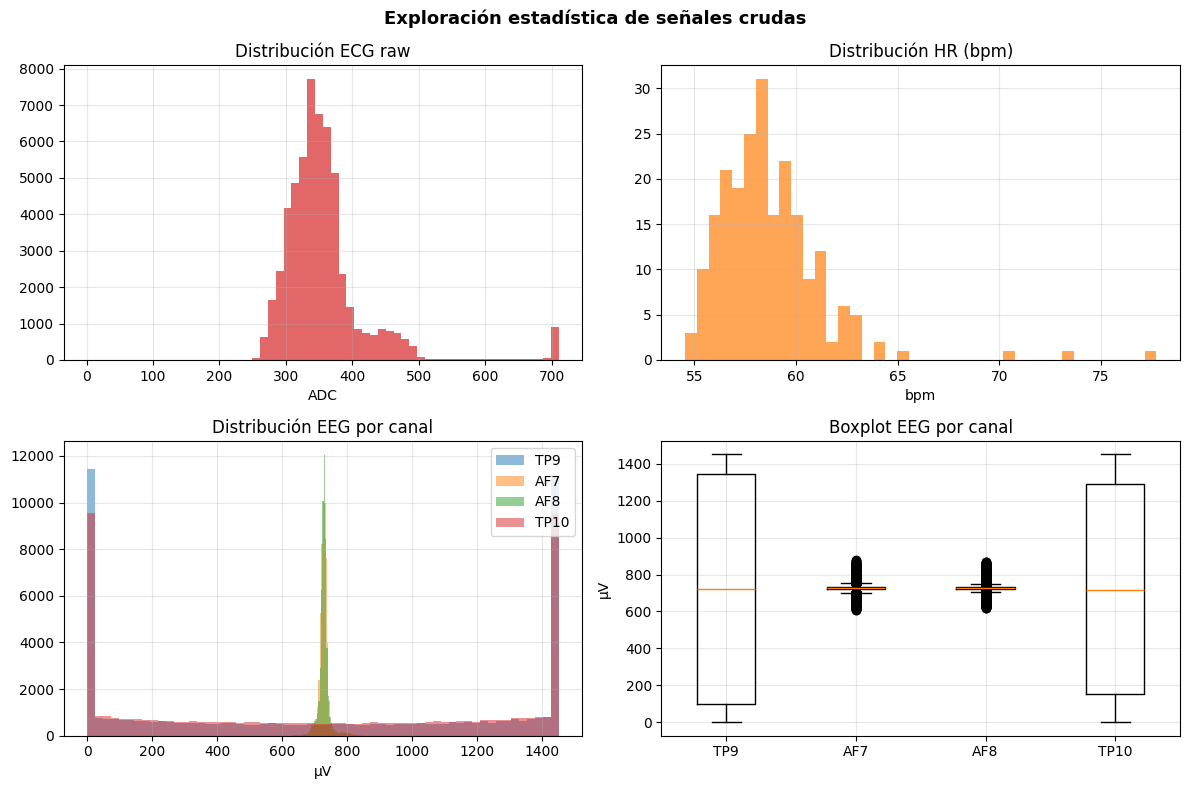

In [61]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Distribución ECG raw
ecg_vals = df_ecg['ecg_raw'].dropna().values
axes[0][0].hist(ecg_vals, bins=60, color='tab:red', alpha=0.7, edgecolor='none')
axes[0][0].set_title('Distribución ECG raw'); axes[0][0].set_xlabel('ADC'); axes[0][0].grid(alpha=0.3)

# Distribución HR
hr_vals = df_ecg['hr_bpm'].dropna().values
axes[0][1].hist(hr_vals, bins=40, color='tab:orange', alpha=0.7, edgecolor='none')
axes[0][1].set_title('Distribución HR (bpm)'); axes[0][1].set_xlabel('bpm'); axes[0][1].grid(alpha=0.3)

# Distribución EEG por canal
for col, name in zip(eeg_cols, CH_NAMES):
    vals = df_eeg[col].dropna().values
    axes[1][0].hist(vals, bins=60, alpha=0.5, label=name, edgecolor='none')
axes[1][0].set_title('Distribución EEG por canal'); axes[1][0].set_xlabel('µV')
axes[1][0].legend(); axes[1][0].grid(alpha=0.3)

# Boxplot EEG
axes[1][1].boxplot([df_eeg[col].dropna().values for col in eeg_cols], labels=CH_NAMES)
axes[1][1].set_title('Boxplot EEG por canal'); axes[1][1].set_ylabel('µV'); axes[1][1].grid(alpha=0.3)

plt.suptitle('Exploración estadística de señales crudas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [62]:
WINDOW_SEC = 8
OVERLAP    = 0.5

WIN  = int(WINDOW_SEC * SYNC_FS)
STEP = int(WIN * (1 - OVERLAP))
N    = (len(t_common) - WIN) // STEP

Picos R detectados: 298
HR estimado: 81.5 bpm


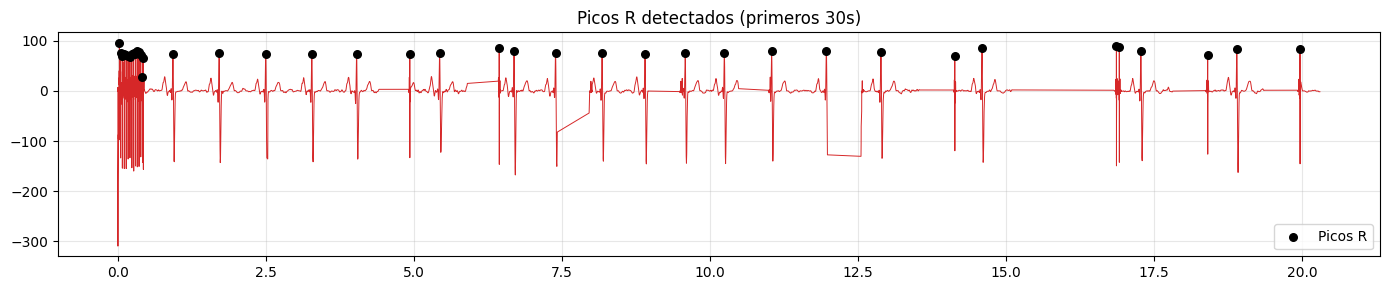

In [128]:
from scipy.signal import find_peaks

# ── Detecta picos R sobre la señal a 250 Hz (antes de sincronizar) ──
ecg_mean = ecg_clean.mean()
ecg_std  = ecg_clean.std()
r_peaks, _ = find_peaks(ecg_clean,
                         height=ecg_mean + 0.8 * ecg_std,
                         distance=int(ECG_FS * 0.4))  # 0.4s mínimo entre picos

# Convierte índices de picos a tiempo (segundos)
r_peak_times = ecg_t[r_peaks]  # tiempo real en segundos desde t0

print(f"Picos R detectados: {len(r_peaks)}")
print(f"HR estimado: {60 / np.diff(r_peak_times).mean():.1f} bpm")

# Verifica visualmente
fig, ax = plt.subplots(figsize=(14, 3))
t_plot = ecg_t[:ECG_FS * 30]
ax.plot(t_plot, ecg_clean[:ECG_FS * 30], lw=0.7, color='tab:red')
peaks_in_window = r_peaks[r_peaks < ECG_FS * 30]
ax.scatter(ecg_t[peaks_in_window], ecg_clean[peaks_in_window],
           color='black', s=30, zorder=5, label='Picos R')
ax.set_title('Picos R detectados (primeros 30s)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('report/MDPI_Article_Template/figures/r_peaks_deteccion.png', dpi=150, bbox_inches='tight')
plt.show()

# 5. Extracción de features

Se extraen features de cada ventana de 8 segundos con 50% de overlap sobre las señales
filtradas. Las ventanas contaminadas se descartan antes de extraer cualquier feature.

### Decisiones de diseño

**Ventana de 8 segundos:** es el mínimo para estimar LF/HF de la HRV con resolución
frecuencial aceptable (resolución = 1/8 Hz = 0.125 Hz, suficiente para separar LF
de HF cuyo límite está en 0.15 Hz). Ventanas más cortas producen estimaciones
inestables de las bandas frecuenciales.

**50% de overlap:** aumenta el número de ventanas sin introducir dependencia excesiva
entre muestras consecutivas. Es el estándar en procesamiento de señales biológicas.


## Features ECG

Se extraen 11 features por ventana en dos dominios:

**Dominio temporal (HRV):** mean_RR, SDNN, RMSSD, HR_mean, HR_std, HR_min, HR_max,
pNN50. Capturan la variabilidad del ritmo cardíaco momento a momento. RMSSD y pNN50
son especialmente sensibles al sistema nervioso parasimpático, asociado con estados
de calma y valencia positiva.

**Dominio frecuencial:** LF (0.04–0.15 Hz), HF (0.15–0.4 Hz), LF/HF ratio.
LF refleja actividad simpática y parasimpática (arousal), HF refleja actividad
parasimpática pura (relajación). El ratio LF/HF es el índice de balance autonómico
más usado en reconocimiento de emociones.

### Decisión clave: `band_power_rr` en lugar de `band_power`

Los intervalos RR son irregularmente espaciados en el tiempo (cada latido llega en
un momento distinto). Aplicar Welch directamente sobre el array RR asumiría que son
igualmente espaciados, lo cual produce estimaciones incorrectas de LF y HF.
La solución es interpolar los RR a una cuadrícula uniforme de 4 Hz antes de aplicar
Welch — este es el método estándar en análisis de HRV (Task Force, 1996).

### `extract_ecg_features`: función unificada con dos modos

La función acepta dos modos de operación para garantizar consistencia entre el
pipeline exploratorio y el batch:
- **Modo picos pre-detectados** (exploratorio): recibe `r_peak_times_session` y filtra
  los picos que caen en la ventana. Más preciso porque los picos se detectaron con
  contexto global.
- **Modo señal cruda** (fallback): detecta picos internamente sobre `ecg_win`.
Ambos modos producen exactamente las mismas 11 features de salida.


In [64]:
from scipy.signal import find_peaks, welch
from scipy.interpolate import interp1d

def band_power(signal, fs, fmin, fmax):
    """PSD sobre señal genérica (EEG, etc.)."""
    freqs, psd = welch(signal, fs=fs, nperseg=min(len(signal), fs * 2))
    idx = (freqs >= fmin) & (freqs <= fmax)
    return float(np.trapezoid(psd[idx], freqs[idx]))

def band_power_rr(rr_ms, fs_resample=4.0, fmin=0.04, fmax=0.40):
    """
    Potencia espectral de los intervalos RR en una banda de frecuencia.
    Los RR se interpolan a una cuadrícula uniforme (4 Hz) antes de aplicar
    Welch, porque los intervalos RR son irregularmente espaciados en el tiempo.
    Usar band_power() directamente sobre el array RR sería incorrecto.
    """
    if len(rr_ms) < 4:
        return np.nan
    t_rr = np.cumsum(rr_ms) / 1000.0
    t_rr = t_rr - t_rr[0]
    t_uni = np.arange(0, t_rr[-1], 1.0 / fs_resample)
    if len(t_uni) < 8:
        return np.nan
    rr_uni = interp1d(t_rr, rr_ms, kind='cubic', fill_value='extrapolate')(t_uni)
    nperseg = min(len(rr_uni), max(8, len(rr_uni) // 2))
    freqs, psd = welch(rr_uni, fs=fs_resample, nperseg=nperseg)
    idx = (freqs >= fmin) & (freqs <= fmax)
    return float(np.trapezoid(psd[idx], freqs[idx])) if idx.any() else np.nan

def extract_ecg_features(ecg_win, fs, r_peak_times_session=None, t_win_start=None, t_win_end=None):
    """
    Extrae features HRV de una ventana ECG.

    Acepta dos modos:
      - Modo señal (batch):  extract_ecg_features(ecg_win, fs)
        Detecta picos R internamente sobre ecg_win.
      - Modo picos (exploratorio): extract_ecg_features(ecg_win, fs,
            r_peak_times_session, t_win_start, t_win_end)
        Filtra los picos R de la sesión que caen en [t_win_start, t_win_end].
        Más preciso porque los picos se detectaron sobre la señal completa.
    """
    if r_peak_times_session is not None:
        # Modo picos pre-detectados
        mask = (r_peak_times_session >= t_win_start) & (r_peak_times_session <= t_win_end)
        r_times = r_peak_times_session[mask]
        if len(r_times) < 3:
            return None
        rr = np.diff(r_times) * 1000.0
    else:
        # Modo señal cruda
        m, s = ecg_win.mean(), ecg_win.std()
        if s == 0:
            return None
        peaks, _ = find_peaks(ecg_win, height=m + 0.8 * s, distance=int(fs * 0.4))
        if len(peaks) < 3:
            return None
        rr = np.diff(peaks) / fs * 1000.0

    rr = rr[(rr > 300) & (rr < 1500)]
    if len(rr) < 2:
        return None

    f = {}
    f['ecg_mean_rr'] = rr.mean()
    f['ecg_sdnn']    = rr.std()
    f['ecg_rmssd']   = float(np.sqrt(np.mean(np.diff(rr) ** 2)))
    f['ecg_hr_mean'] = 60_000 / rr.mean()
    f['ecg_hr_std']  = (60_000 / rr).std()
    f['ecg_hr_min']  = (60_000 / rr).min()
    f['ecg_hr_max']  = (60_000 / rr).max()
    f['ecg_pnn50']   = np.sum(np.abs(np.diff(rr)) > 50) / len(rr) * 100
    f['ecg_lf']    = band_power_rr(rr, fmin=0.04, fmax=0.15)
    f['ecg_hf']    = band_power_rr(rr, fmin=0.15, fmax=0.40)
    f['ecg_lf_hf'] = (f['ecg_lf'] / (f['ecg_hf'] + 1e-9)
                      if not (np.isnan(f['ecg_lf']) or np.isnan(f['ecg_hf'])) else np.nan)
    return f

print('extract_ecg_features unificada — lista.')


extract_ecg_features unificada — lista.


## Features EEG

Se extraen ~46 features por ventana en tres grupos:

**Potencia por banda (20 features):** Delta (1–4 Hz), Theta (4–8 Hz), Alpha (8–13 Hz),
Beta (13–30 Hz), Gamma (30–45 Hz) para cada uno de los 4 canales. Son la base de la
mayoría de clasificadores de emoción basados en EEG.

**Estadísticas temporales (16 features):** media, std, kurtosis y skew por canal.
Complementan las features espectrales capturando características de la distribución
de amplitud.

**Asimetría frontal (10 features):** DASM (diferencia) y RASM (ratio) entre AF7 y AF8
para las 5 bandas. La asimetría alfa frontal está fuertemente asociada con la dimensión
de valencia emocional (teoría de Davidson, 1993).

**Coherencia AF7–AF8 (1 feature):** correlación de Pearson entre los canales frontales.
Mide la sincronización interhemisférica, relevante para el procesamiento emocional.

### Decisión: umbrales adaptativos por sesión

Se usan percentiles 99 de amplitud y kurtosis calculados sobre todas las ventanas
de la sesión como umbrales de rechazo, en lugar de valores fijos. Esto evita descartar
señal válida de participantes con mayor amplitud basal de EEG.


In [65]:
def eeg_bands(signal, fs):
    return {
        'delta': band_power(signal, fs, 1,  4),
        'theta': band_power(signal, fs, 4,  8),
        'alpha': band_power(signal, fs, 8,  13),
        'beta':  band_power(signal, fs, 13, 30),
        'gamma': band_power(signal, fs, 30, 45),
    }

def extract_eeg_features(eeg_win_dict, fs, amp_threshold=400.0, kurt_threshold=10.0):
    f, bpows = {}, {}
    for name in CH_NAMES:
        sig = eeg_win_dict[name]
        if len(sig) < fs:
            return None
        # Ahora usa los umbrales que se le pasen
        if (sig.max() - sig.min()) > amp_threshold or kurtosis(sig) > kurt_threshold:
            return None
        bp = {b: band_power(sig, fs, *r)
              for b, r in [('delta',(1,4)), ('theta',(4,8)),
                            ('alpha',(8,13)), ('beta',(13,30)), ('gamma',(30,45))]}
        bpows[name] = bp
        for band, val in bp.items():
            f[f'eeg_{name}_{band}'] = val
        f[f'eeg_{name}_mean'] = sig.mean()
        f[f'eeg_{name}_std']  = sig.std()
        f[f'eeg_{name}_kurt'] = kurtosis(sig)
        f[f'eeg_{name}_skew'] = skew(sig)
    for band in ['delta','theta','alpha','beta','gamma']:
        af7 = bpows['AF7'][band]
        af8 = bpows['AF8'][band]
        f[f'eeg_dasm_{band}'] = af8 - af7
        f[f'eeg_rasm_{band}'] = (af8 - af7) / (af8 + af7 + 1e-9)
    min_len = min(len(eeg_win_dict['AF7']), len(eeg_win_dict['AF8']))
    f['eeg_coherence_af7_af8'] = float(np.corrcoef(
        eeg_win_dict['AF7'][:min_len], eeg_win_dict['AF8'][:min_len])[0, 1])
    return f

print('Función de features EEG definida.')

Función de features EEG definida.


## Ventaneo y extracción

Se procesa cada ventana de 8 s con 50% de overlap. Las ventanas contaminadas (identificadas 
en el reporte de calidad) se saltan automáticamente.

In [66]:
all_features = []

for w in range(N):
    s, e = w * STEP, w * STEP + WIN
    t_win_start = t_common[s]
    t_win_end   = t_common[e - 1]
    eeg_win = {name: eeg_clean_sync[name][s:e] for name in CH_NAMES}

    # Usa picos R pre-detectados sobre la señal completa (modo preciso)
    ecg_feats = extract_ecg_features(
        None, SYNC_FS,
        r_peak_times_session=r_peak_times,
        t_win_start=t_win_start,
        t_win_end=t_win_end
    )
    eeg_feats = extract_eeg_features(eeg_win, SYNC_FS,
                                      amp_threshold=amp_p99,
                                      kurt_threshold=kurt_p99)

    if ecg_feats is None or eeg_feats is None:
        continue

    row = {'window': w, 'window_start_sec': round(t_win_start, 2)}
    row.update(ecg_feats)
    row.update(eeg_feats)
    all_features.append(row)

df_features = pd.DataFrame(all_features)
print(f'Ventanas válidas  : {len(df_features)}')
print(f'Features extraídas: {len(df_features.columns) - 2}')
print(f'\nNaNs en features ECG frecuenciales:')
print(df_features[['ecg_lf','ecg_hf','ecg_lf_hf']].isna().sum())

features_path = ECG_FILE.with_stem(ECG_FILE.stem + '_features')
df_features.to_csv(features_path, index=False)
print(f'Guardado en: {features_path}')


Ventanas válidas  : 46
Features extraídas: 58

NaNs en features ECG frecuenciales:
ecg_lf       46
ecg_hf        6
ecg_lf_hf    46
dtype: int64
Guardado en: recordings/subject_1/sub1_Moi_30_ad8232_ecg_20260408_103943_features.csv


## Exploración de features

Antes de entrenar cualquier modelo es importante analizar la distribución y correlación de 
las features para detectar redundancias, outliers o features con varianza cercana a cero.

In [67]:
import seaborn as sns

feat_cols = [c for c in df_features.columns if c not in ['window', 'window_start_sec']]

print('Estadísticas de features:')
print(df_features[feat_cols].describe().round(3))
print(f'\nFeatures con NaN: {df_features[feat_cols].isna().any().sum()}')

Estadísticas de features:
       ecg_mean_rr  ecg_sdnn  ecg_rmssd  ecg_hr_mean  ecg_hr_std  ecg_hr_min  \
count       46.000    46.000     46.000       46.000      46.000      46.000   
mean      1015.241   143.871    240.846       59.210      11.098      49.964   
std         43.190   106.952    190.662        2.672      10.796       6.031   
min        893.844    21.511     24.691       56.083       1.220      40.428   
25%        998.398    29.311     39.743       57.511       1.656      43.966   
50%       1025.455   157.315    245.476       58.511       9.381      52.048   
75%       1043.273   239.540    405.815       60.097      16.255      55.625   
max       1069.840   352.844    630.821       67.126      44.762      57.577   

       ecg_hr_max  ecg_pnn50  ecg_lf  ecg_hf  ...  eeg_rasm_delta  \
count      46.000     46.000     0.0    40.0  ...          46.000   
mean       82.782     52.958     NaN     0.0  ...           0.189   
std        27.963     31.335     NaN     0.0  

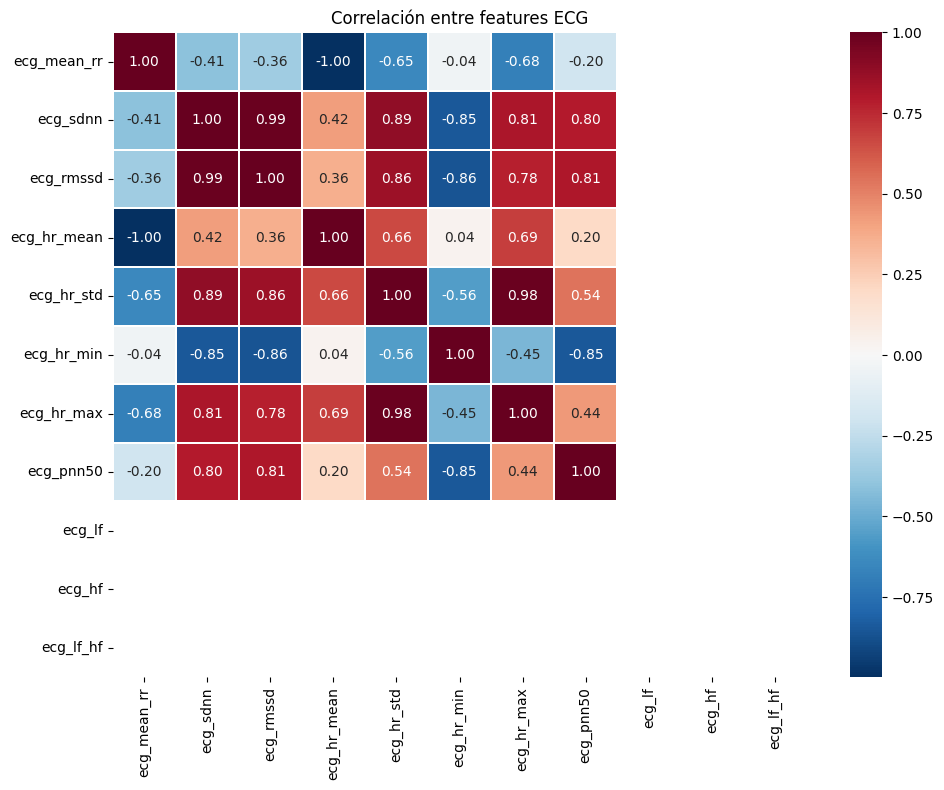

In [125]:
# Heatmap de correlación — features ECG
ecg_feat_cols = [c for c in feat_cols if c.startswith('ecg')]
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(df_features[ecg_feat_cols].corr(), annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, ax=ax, linewidths=0.3)
ax.set_title('Correlación entre features ECG')
plt.tight_layout()
plt.savefig('report/MDPI_Article_Template/figures/correlacion_features_ecg.png', dpi=150, bbox_inches='tight')
plt.show()

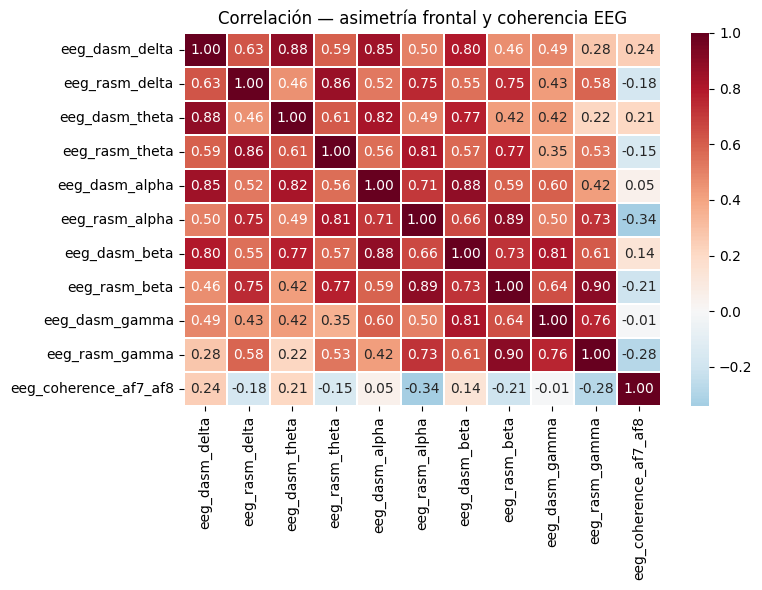

In [124]:
# Heatmap de correlación — asimetría frontal EEG
dasm_cols = [c for c in feat_cols if 'dasm' in c or 'rasm' in c or 'coherence' in c]
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(df_features[dasm_cols].corr(), annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, ax=ax, linewidths=0.3)
ax.set_title('Correlación — asimetría frontal y coherencia EEG')
plt.tight_layout()
plt.savefig('report/MDPI_Article_Template/figures/correlacion_asimetria_eeg.png', dpi=150, bbox_inches='tight')
plt.show()

# 6. Análisis de voz

Después del estímulo emocional, el sujeto lee una frase arbitraria en voz alta
grabada con el teléfono. Esta modalidad complementa las señales fisiológicas con
información de la expresión vocal de la emoción.

### Decisiones de diseño

**Por qué audio:** la voz es una de las señales más estudiadas en reconocimiento
de emociones. El estado emocional modifica la tensión de las cuerdas vocales, la
presión subglótica y el control motor del habla, produciendo cambios medibles en
pitch, energía y espectro.

**Frase arbitraria (no espontánea):** la frase leída tiene menor variabilidad
emocional que el habla espontánea, pero es más fácil de estandarizar entre sujetos.
Es un compromiso entre control experimental y naturalidad.

**Teléfono como micrófono:** accesible y portable, pero introduce compresión de audio
(especialmente .m4a en iPhone) que puede afectar los MFCCs de alta frecuencia.
Se recomienda grabar en formato sin pérdida (.wav) cuando sea posible.

**Fusión por repetición:** las features de audio son globales por grabación (un vector
por sesión), mientras que las de EEG y ECG son por ventana de 8 s. Se repite el
vector de audio en cada fila del dataframe — asume estado emocional estable durante
la sesión, razonable dado el protocolo experimental.


## Carga del archivo de audio

Se acepta cualquier formato soportado por librosa (.wav, .mp3, .m4a, .ogg).
Si el archivo viene del teléfono en .m4a (iPhone) o .opus (Android), librosa lo lee
directamente siempre que ffmpeg esté instalado (`sudo apt install ffmpeg`).

In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import librosa
import librosa.display
import warnings
warnings.filterwarnings('ignore')

# ── Parámetros ────────────────────────────────────────────────
AUDIO_FILE = Path('audio/Moi_30.m4a')  # <-- cambia la ruta
AUDIO_FS   = 22050  # librosa remuestrea a 22050 Hz por defecto

if not AUDIO_FILE.exists():
    raise FileNotFoundError(
        f'No se encontro: {AUDIO_FILE}\n'
        f'Transfiere el archivo del telefono y actualiza AUDIO_FILE.'
    )

audio, sr = librosa.load(AUDIO_FILE, sr=AUDIO_FS, mono=True)
duracion = len(audio) / sr

print(f'Archivo  : {AUDIO_FILE.name}')
print(f'Duracion : {duracion:.2f} s')
print(f'Muestras : {len(audio)}')
print(f'Fs       : {sr} Hz')

Archivo  : Moi_30.m4a
Duracion : 3.23 s
Muestras : 71168
Fs       : 22050 Hz


## Visualización de la señal de voz

Se grafican la forma de onda, el espectrograma Mel y la energía RMS para verificar que
el audio se cargó correctamente y detectar ruido de fondo, silencios excesivos o saturación.

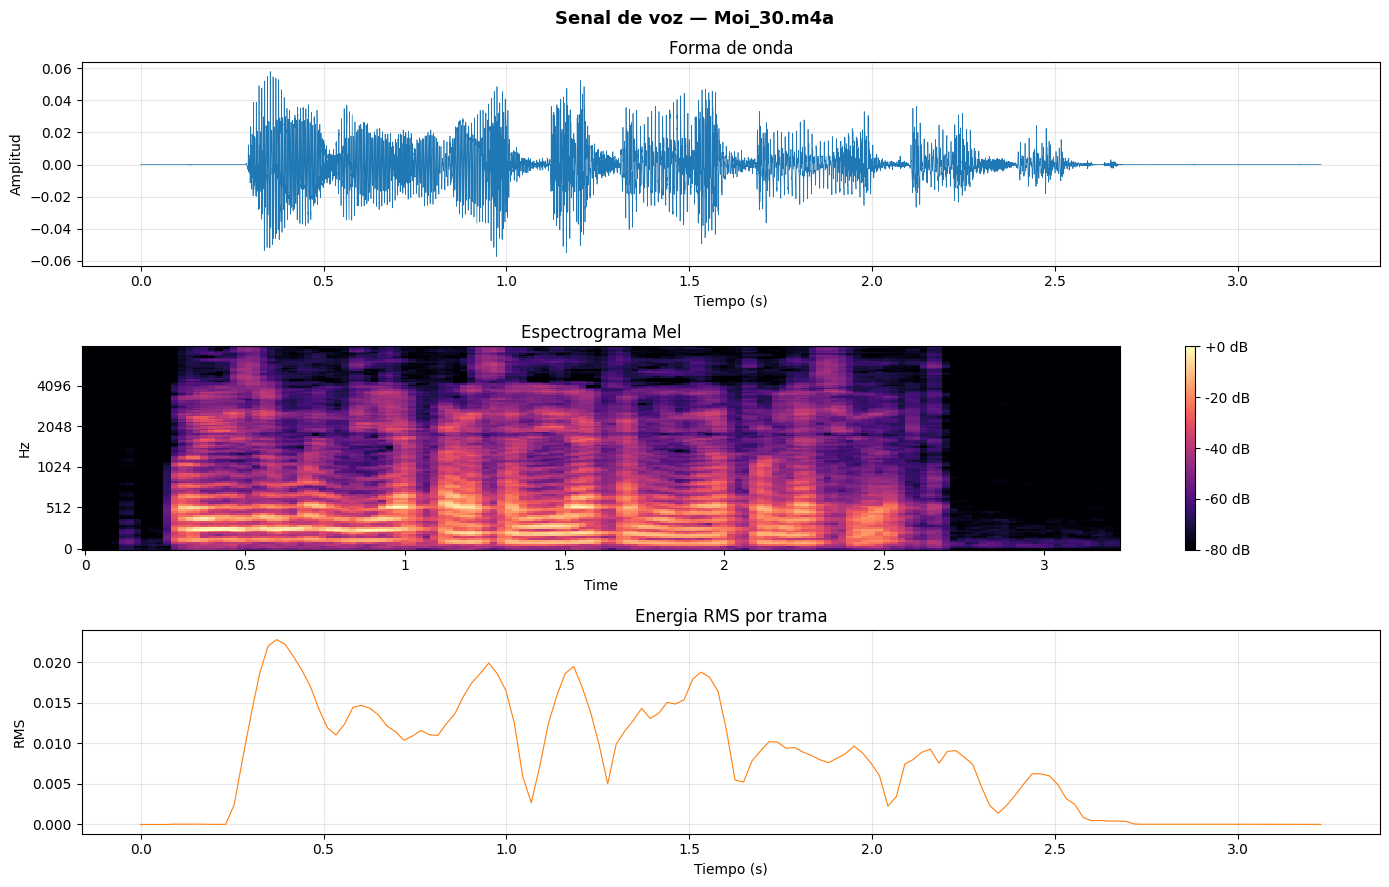

In [130]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9))

t_audio = np.linspace(0, duracion, len(audio))
axes[0].plot(t_audio, audio, color='tab:blue', lw=0.5)
axes[0].set_title('Forma de onda')
axes[0].set_ylabel('Amplitud'); axes[0].set_xlabel('Tiempo (s)')
axes[0].grid(alpha=0.3)

S = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=128, fmax=8000)
S_dB = librosa.power_to_db(S, ref=np.max)
img = librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel',
                                fmax=8000, ax=axes[1])
fig.colorbar(img, ax=axes[1], format='%+2.0f dB')
axes[1].set_title('Espectrograma Mel')

rms_viz = librosa.feature.rms(y=audio, frame_length=2048, hop_length=512)[0]
t_rms_viz = librosa.frames_to_time(np.arange(len(rms_viz)), sr=sr, hop_length=512)
axes[2].plot(t_rms_viz, rms_viz, color='tab:orange', lw=0.8)
axes[2].set_title('Energia RMS por trama')
axes[2].set_ylabel('RMS'); axes[2].set_xlabel('Tiempo (s)')
axes[2].grid(alpha=0.3)

plt.suptitle(f'Senal de voz — {AUDIO_FILE.name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('report/MDPI_Article_Template/figures/audio_waveform_espectrograma.png', dpi=150, bbox_inches='tight')
plt.show()

## Preprocesamiento del audio

**Recorte de silencios:** elimina el inicio y final donde el sujeto posiciona o baja el
teléfono. `librosa.effects.trim` usa un umbral de 20 dB por debajo del pico máximo.

**Pre-énfasis:** filtro de alta frecuencia que compensa la caída natural del espectro vocal.
Mejora la calidad de los MFCCs. El coeficiente estándar es 0.97.

Audio original : 3.23 s
Recortado      : 2.32 s  [0.26s – 2.58s]


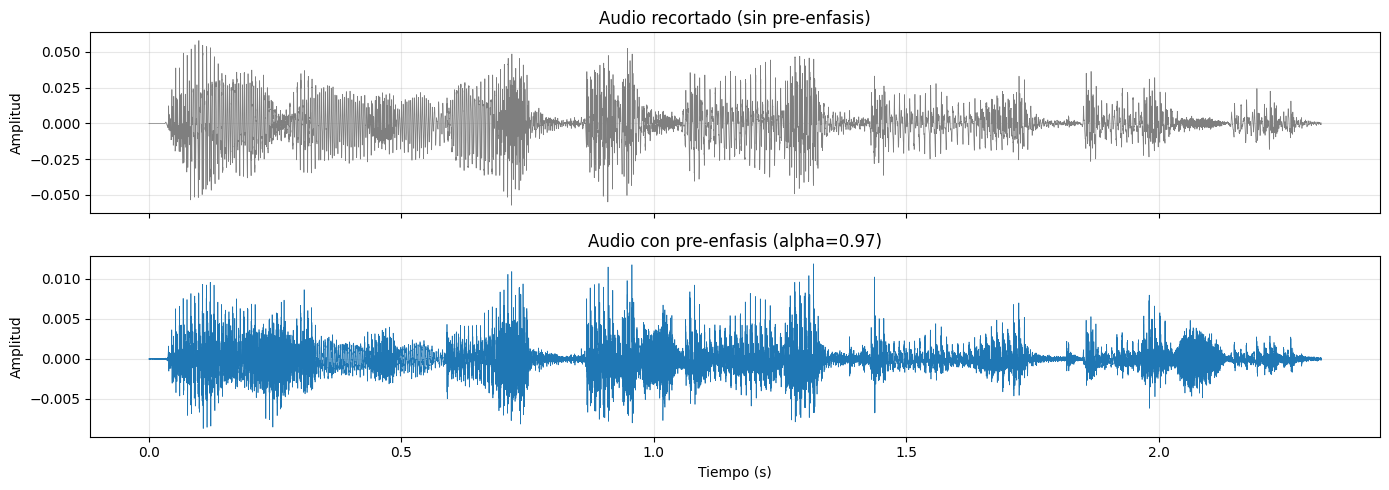

In [131]:
audio_trimmed, trim_idx = librosa.effects.trim(audio, top_db=20)
t_start = trim_idx[0] / sr
t_end   = trim_idx[1] / sr
print(f'Audio original : {duracion:.2f} s')
print(f'Recortado      : {len(audio_trimmed)/sr:.2f} s  [{t_start:.2f}s – {t_end:.2f}s]')

PRE_EMPHASIS = 0.97
audio_proc = np.append(audio_trimmed[0],
                        audio_trimmed[1:] - PRE_EMPHASIS * audio_trimmed[:-1])

fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
t_trim = np.linspace(0, len(audio_trimmed)/sr, len(audio_trimmed))
axes[0].plot(t_trim, audio_trimmed, lw=0.5, color='tab:gray')
axes[0].set_title('Audio recortado (sin pre-enfasis)')
axes[0].set_ylabel('Amplitud'); axes[0].grid(alpha=0.3)

axes[1].plot(t_trim, audio_proc, lw=0.5, color='tab:blue')
axes[1].set_title('Audio con pre-enfasis (alpha=0.97)')
axes[1].set_ylabel('Amplitud'); axes[1].set_xlabel('Tiempo (s)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('report/MDPI_Article_Template/figures/audio_preenfasis.png', dpi=150, bbox_inches='tight')
plt.show()

## Extracción de features acústicas

Se extraen tres grupos de features:

**MFCC + deltas (39 features base):** los 13 coeficientes cepstrales más sus deltas y
delta-deltas capturan la forma del tracto vocal y su evolución temporal, que cambia con
el estado emocional.

**Pitch F0 (PYIN):** la frecuencia fundamental de la voz. Sube en alta activación (miedo,
alegría) y baja en calma o tristeza. PYIN es más robusto que YIN para voz con ruido.

**Energía y características espectrales:** RMS, centroide, ancho de banda, rolloff y ZCR
capturan cambios en la intensidad y distribución de energía asociados con el arousal.

In [73]:
HOP_LENGTH = 512
N_MFCC     = 13

mfcc        = librosa.feature.mfcc(y=audio_proc, sr=sr, n_mfcc=N_MFCC, hop_length=HOP_LENGTH)
mfcc_delta  = librosa.feature.delta(mfcc)
mfcc_delta2 = librosa.feature.delta(mfcc, order=2)

f0, voiced_flag, voiced_prob = librosa.pyin(
    audio_proc, sr=sr,
    fmin=librosa.note_to_hz('C2'),
    fmax=librosa.note_to_hz('C7'),
    hop_length=HOP_LENGTH
)
f0_voiced = f0[voiced_flag]

rms      = librosa.feature.rms(y=audio_proc, hop_length=HOP_LENGTH)[0]
centroid = librosa.feature.spectral_centroid(y=audio_proc, sr=sr, hop_length=HOP_LENGTH)[0]
bandwidth= librosa.feature.spectral_bandwidth(y=audio_proc, sr=sr, hop_length=HOP_LENGTH)[0]
rolloff  = librosa.feature.spectral_rolloff(y=audio_proc, sr=sr, hop_length=HOP_LENGTH)[0]
zcr      = librosa.feature.zero_crossing_rate(audio_proc, hop_length=HOP_LENGTH)[0]

print(f'MFCCs extraidos    : {mfcc.shape}  (coef x tramas)')
print(f'Tramas con voz     : {voiced_flag.sum()} / {len(voiced_flag)}')
if len(f0_voiced) > 0:
    print(f'F0 media           : {np.nanmean(f0_voiced):.1f} Hz')
    print(f'F0 rango           : {np.nanmin(f0_voiced):.1f} – {np.nanmax(f0_voiced):.1f} Hz')

MFCCs extraidos    : (13, 101)  (coef x tramas)
Tramas con voz     : 65 / 101
F0 media           : 118.6 Hz
F0 rango           : 90.9 – 153.8 Hz


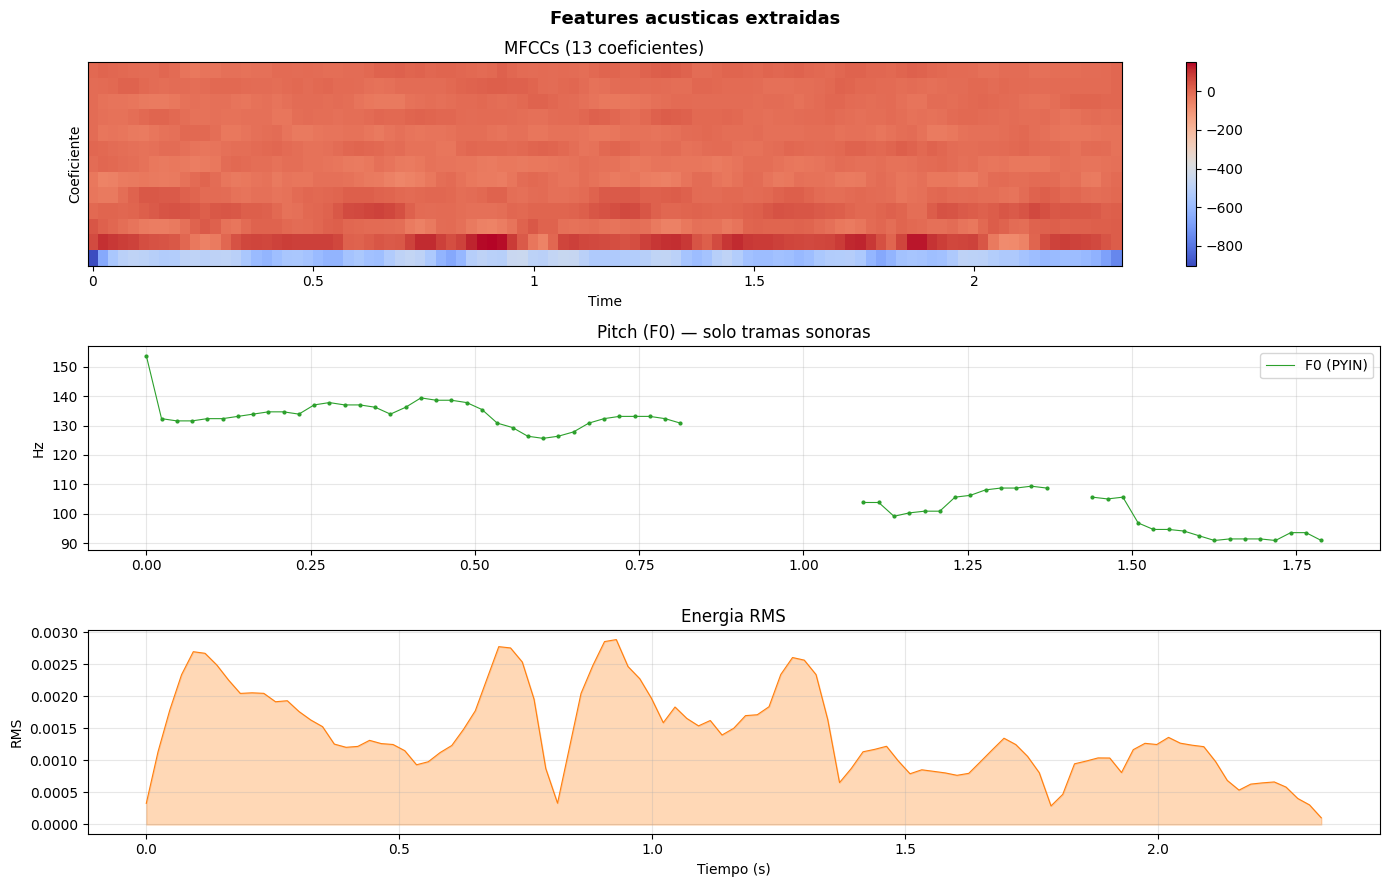

In [ ]:
t_frames = librosa.frames_to_time(np.arange(mfcc.shape[1]), sr=sr, hop_length=HOP_LENGTH)

fig, axes = plt.subplots(3, 1, figsize=(14, 9))

img = librosa.display.specshow(mfcc, sr=sr, x_axis='time',
                                hop_length=HOP_LENGTH, ax=axes[0])
fig.colorbar(img, ax=axes[0])
axes[0].set_title(f'MFCCs ({N_MFCC} coeficientes)')
axes[0].set_ylabel('Coeficiente')

t_f0 = librosa.frames_to_time(np.arange(len(f0)), sr=sr, hop_length=HOP_LENGTH)
axes[1].plot(t_f0, f0, color='tab:green', lw=0.8, label='F0 (PYIN)')
axes[1].scatter(t_f0[voiced_flag], f0[voiced_flag], s=4, color='tab:green', zorder=3)
axes[1].set_title('Pitch (F0) — solo tramas sonoras')
axes[1].set_ylabel('Hz'); axes[1].grid(alpha=0.3); axes[1].legend()

t_rms2 = librosa.frames_to_time(np.arange(len(rms)), sr=sr, hop_length=HOP_LENGTH)
axes[2].plot(t_rms2, rms, color='tab:orange', lw=0.8)
axes[2].fill_between(t_rms2, rms, alpha=0.3, color='tab:orange')
axes[2].set_title('Energia RMS')
axes[2].set_ylabel('RMS'); axes[2].set_xlabel('Tiempo (s)'); axes[2].grid(alpha=0.3)

plt.suptitle('Features acusticas extraidas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('report/MDPI_Article_Template/figures/audio_features_acusticas.png', dpi=150, bbox_inches='tight')
plt.show()

## Agregación de features por grabación

Las features se calculan trama a trama (~23 ms cada una). Para combinarlas con las features
de EEG y ECG (por ventana de 8 s) se calculan estadísticas descriptivas sobre todas las
tramas: media, desviación estándar, mínimo, máximo y percentil 75. Este enfoque es el
estándar en sistemas como openSMILE y el challenge INTERSPEECH.

In [75]:
def aggregate_feature(arr, name):
    arr = arr[~np.isnan(arr)]
    if len(arr) == 0:
        return {name+'_mean': np.nan, name+'_std': np.nan,
                name+'_min':  np.nan, name+'_max': np.nan, name+'_p75': np.nan}
    return {
        name+'_mean': float(arr.mean()),
        name+'_std' : float(arr.std()),
        name+'_min' : float(arr.min()),
        name+'_max' : float(arr.max()),
        name+'_p75' : float(np.percentile(arr, 75)),
    }

audio_feats = {}
for i in range(N_MFCC):
    audio_feats.update(aggregate_feature(mfcc[i],        'mfcc_'+str(i+1)))
    audio_feats.update(aggregate_feature(mfcc_delta[i],  'mfcc_d_'+str(i+1)))
    audio_feats.update(aggregate_feature(mfcc_delta2[i], 'mfcc_dd_'+str(i+1)))

f0_input = f0_voiced if len(f0_voiced) > 0 else np.array([np.nan])
audio_feats.update(aggregate_feature(f0_input, 'f0'))
audio_feats['f0_voiced_ratio'] = float(voiced_flag.sum() / len(voiced_flag))

audio_feats.update(aggregate_feature(rms,       'rms'))
audio_feats.update(aggregate_feature(centroid,  'spectral_centroid'))
audio_feats.update(aggregate_feature(bandwidth, 'spectral_bandwidth'))
audio_feats.update(aggregate_feature(rolloff,   'spectral_rolloff'))
audio_feats.update(aggregate_feature(zcr,       'zcr'))

df_audio_feats = pd.DataFrame([audio_feats])
print('Features de audio extraidas:', len(audio_feats))

audio_features_path = AUDIO_FILE.with_suffix('').with_name(AUDIO_FILE.stem + '_features.csv')
df_audio_feats.to_csv(audio_features_path, index=False)
print('Guardado en:', audio_features_path)

Features de audio extraidas: 226
Guardado en: audio/Moi_30_features.csv


# 7. Construcción del dataset definitivo

Las secciones anteriores muestran el pipeline paso a paso para una sesión de ejemplo.
Esta sección aplica exactamente el mismo pipeline a todas las sesiones simultáneamente
y produce el dataset definitivo listo para entrenar los modelos.

### Decisiones de diseño

**Batch automático:** en lugar de correr el notebook sesión por sesión, el loop
descubre todos los archivos automáticamente usando el patrón de nombre
`sub{N}_{Nombre}_{video}_ad8232_ecg_{timestamp}.csv`. Esto garantiza que no se
omite ninguna sesión por error manual.

**Resolución de duplicados por timestamp:** cuando existen dos archivos para la misma
combinación participante+video (por ejemplo, una grabación interrumpida y relanzada),
se toma automáticamente el más reciente por timestamp en el nombre de archivo.

**Exclusión de baseline:** las grabaciones de baseline (sin estímulo) se excluyen del
dataset de entrenamiento porque no tienen etiqueta SAM asociada. Podrían usarse
en trabajo futuro como referencia de estado neutro por sujeto.

**Etiquetado cruzado por participante+video:** la clave de unión con el CSV de
autoevaluación es `(participante, id_video)`. Se aplica el filtro de calidad
attention ≥ 3 y confidence ≥ 3 para excluir respuestas SAM poco confiables.


## Exploración del CSV de autoevaluación

Antes del batch se analiza la distribución de etiquetas para entender el balance
de clases y detectar posibles problemas antes del entrenamiento.

In [76]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.signal import butter, filtfilt, iirnotch, medfilt, find_peaks, welch
from scipy.stats import kurtosis, skew
import librosa
import warnings
warnings.filterwarnings('ignore')

# ── Parámetros ────────────────────────────────────────────────
OUTPUT_DIR  = Path('recordings')
AUDIO_DIR   = Path('audio')  # <-- carpeta con los .wav del teléfono
SAM_FILE    = Path('autoevaluacion_emocion.csv')
DATASET_DIR = Path('dataset')
DATASET_DIR.mkdir(parents=True, exist_ok=True)

ECG_FS     = 250
EEG_FS     = 256
SYNC_FS    = 100
WINDOW_SEC = 8
OVERLAP    = 0.5
HOP_LENGTH = 512
N_MFCC     = 13
CH_NAMES   = ['TP9','AF7','AF8','TP10']
VIDEOS_VALIDOS = {'30','55','61','62','69'}

# Carga y limpieza SAM
df_sam = pd.read_csv(SAM_FILE, skiprows=1)
df_sam = df_sam[(df_sam['attention'] >= 3) & (df_sam['confidence'] >= 3)].copy()
df_sam['label_valencia']  = (df_sam['valence'] >= 5).astype(int)
df_sam['label_arousal']   = (df_sam['arousal'] >= 5).astype(int)
emo_cats = ['Felicidad','Tristeza','Miedo','Enojo','Asco','Neutral','Otra']
df_sam['label_categoria'] = pd.Categorical(df_sam['label'], categories=emo_cats).codes
df_sam['id_video']        = df_sam['id_video'].astype(str)

print(f'SAM: {len(df_sam)} registros válidos de '
      f'{df_sam["participante"].nunique()} participantes')
print(f'Videos: {sorted(df_sam["id_video"].unique())}')

SAM: 50 registros válidos de 10 participantes
Videos: ['30', '55', '61', '62', '69']


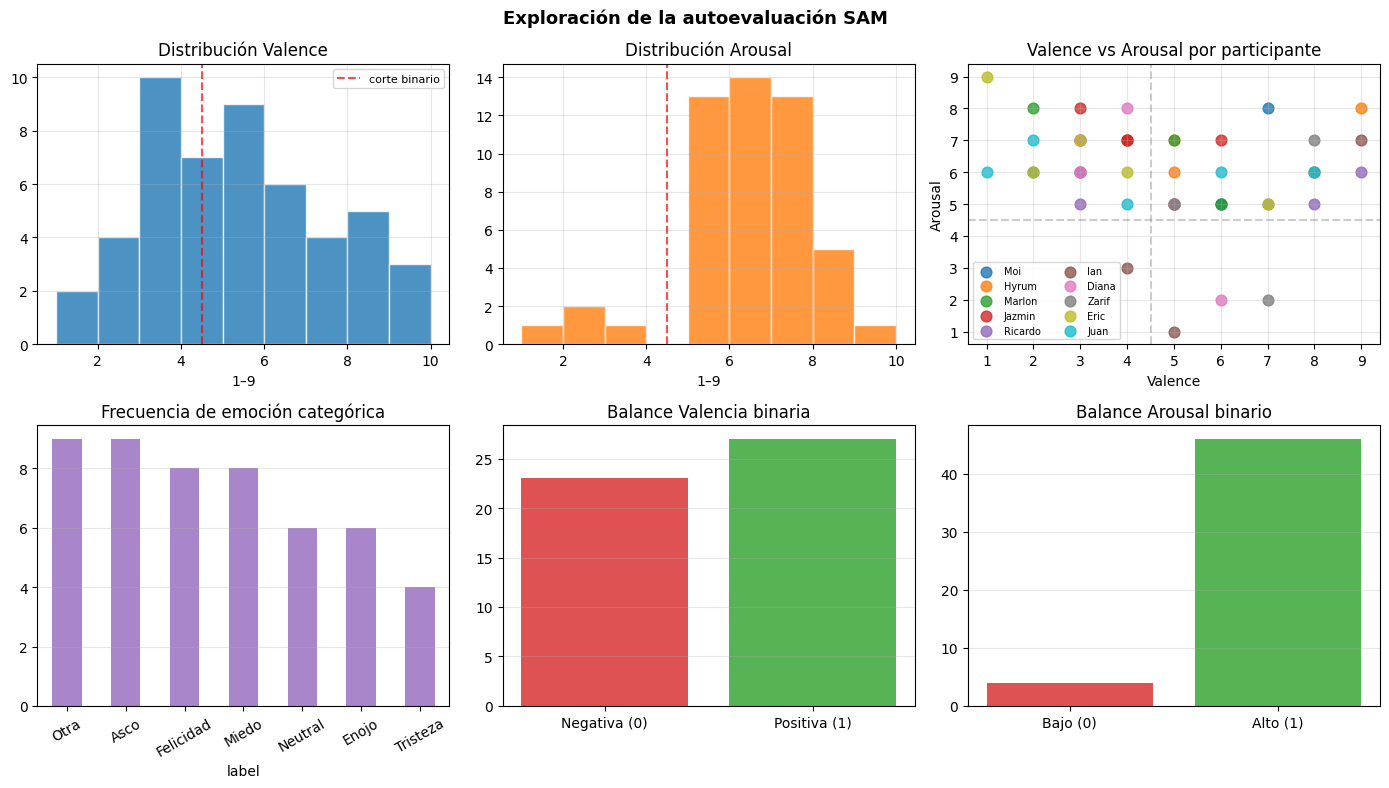

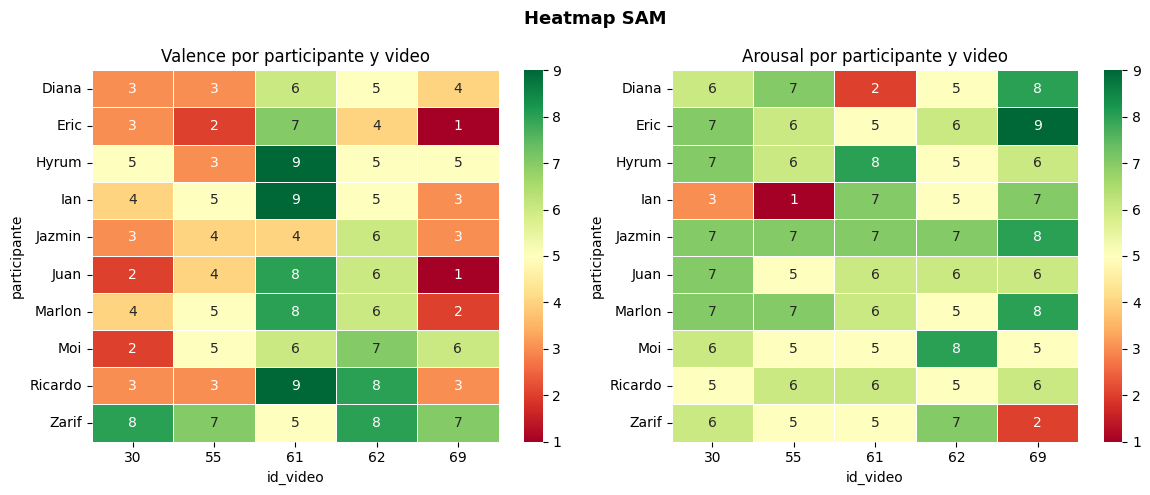

In [123]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

axes[0][0].hist(df_sam['valence'], bins=9, range=(1,10),
                color='tab:blue', alpha=0.8, edgecolor='white')
axes[0][0].axvline(4.5, ls='--', color='red', alpha=0.7, label='corte binario')
axes[0][0].set_title('Distribución Valence'); axes[0][0].set_xlabel('1–9')
axes[0][0].legend(fontsize=8); axes[0][0].grid(alpha=0.3)

axes[0][1].hist(df_sam['arousal'], bins=9, range=(1,10),
                color='tab:orange', alpha=0.8, edgecolor='white')
axes[0][1].axvline(4.5, ls='--', color='red', alpha=0.7)
axes[0][1].set_title('Distribución Arousal'); axes[0][1].set_xlabel('1–9')
axes[0][1].grid(alpha=0.3)

participantes = df_sam['participante'].unique()
cmap = plt.cm.get_cmap('tab10', len(participantes))
for i, p in enumerate(participantes):
    mask = df_sam['participante'] == p
    axes[0][2].scatter(df_sam.loc[mask,'valence'], df_sam.loc[mask,'arousal'],
                       color=cmap(i), label=p, s=60, alpha=0.8)
axes[0][2].axvline(4.5, ls='--', color='gray', alpha=0.4)
axes[0][2].axhline(4.5, ls='--', color='gray', alpha=0.4)
axes[0][2].set_xlabel('Valence'); axes[0][2].set_ylabel('Arousal')
axes[0][2].set_title('Valence vs Arousal por participante')
axes[0][2].legend(fontsize=7, ncol=2); axes[0][2].grid(alpha=0.3)

df_sam['label'].value_counts().plot(kind='bar', ax=axes[1][0],
                                     color='tab:purple', alpha=0.8)
axes[1][0].set_title('Frecuencia de emoción categórica')
axes[1][0].tick_params(axis='x', rotation=30); axes[1][0].grid(alpha=0.3, axis='y')

bv = df_sam['label_valencia']
axes[1][1].bar(['Negativa (0)','Positiva (1)'],
               [(bv==0).sum(),(bv==1).sum()],
               color=['tab:red','tab:green'], alpha=0.8)
axes[1][1].set_title('Balance Valencia binaria'); axes[1][1].grid(alpha=0.3, axis='y')

ba = df_sam['label_arousal']
axes[1][2].bar(['Bajo (0)','Alto (1)'],
               [(ba==0).sum(),(ba==1).sum()],
               color=['tab:red','tab:green'], alpha=0.8)
axes[1][2].set_title('Balance Arousal binario'); axes[1][2].grid(alpha=0.3, axis='y')

plt.suptitle('Exploración de la autoevaluación SAM', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('report/MDPI_Article_Template/figures/sam_exploracion.png', dpi=150, bbox_inches='tight')
plt.show()

# Heatmap por participante y video
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, col in [(axes[0],'valence'),(axes[1],'arousal')]:
    pivot = df_sam.pivot(index='participante', columns='id_video', values=col)
    sns.heatmap(pivot, annot=True, fmt='.0f', cmap='RdYlGn',
                vmin=1, vmax=9, ax=ax, linewidths=0.5)
    ax.set_title(col.capitalize() + ' por participante y video')
plt.suptitle('Heatmap SAM', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('report/MDPI_Article_Template/figures/sam_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


## Descubrimiento de archivos

Se escanea la carpeta `recordings/` buscando todos los pares ECG/EEG válidos.
El patrón de nombre es `sub{N}_{Nombre}_{video}_ad8232_ecg_{timestamp}.csv`.
Los archivos de baseline y los duplicados se resuelven automáticamente:
cuando hay dos archivos para la misma combinación participante+video se toma
el más reciente por timestamp.

In [78]:
PAT = re.compile(
    r'sub(\d+)_([A-Za-z]+)_(\w+)_ad8232_ecg_(\d{8}_\d{6})\.csv', re.IGNORECASE)

# Descubre todos los ECG y agrupa por (participante, video)
candidatos = {}
for ecg_path in sorted(OUTPUT_DIR.glob('**/*_ad8232_ecg_*.csv')):
    m = PAT.search(ecg_path.name)
    if not m: continue
    nombre, video, stamp = m.group(2), m.group(3).lower(), m.group(4)
    if video == 'baseline': continue
    if video not in VIDEOS_VALIDOS: continue
    key = (nombre, video)
    # Toma el más reciente si hay duplicados
    if key not in candidatos or stamp > candidatos[key]['stamp']:
        eeg_name = ecg_path.name.replace('ad8232_ecg', 'openmuse_eeg')
        eeg_path = ecg_path.parent / eeg_name
        if not eeg_path.exists(): continue
        # Busca audio: recordings/audio/{Nombre}_{video}.wav/mp3/m4a
        audio_path = None
        for ext in ['wav','mp3','m4a','ogg']:
            c = AUDIO_DIR / f'{nombre}_{video}.{ext}'
            if c.exists(): audio_path = c; break
        candidatos[key] = {
            'nombre': nombre, 'video': video, 'stamp': stamp,
            'ecg': ecg_path, 'eeg': eeg_path, 'audio': audio_path
        }

sesiones = list(candidatos.values())
print(f'Sesiones válidas encontradas: {len(sesiones)}')
print(f'{'Participante':12} {'Video':6} {'Audio':6} {'ECG':50}')
print('-'*80)
for s in sesiones:
    audio_tag = 'si' if s['audio'] else 'no'
    print(f'{s["nombre"]:12} {s["video"]:6} {audio_tag:6} {s["ecg"].name}')

Sesiones válidas encontradas: 50
Participante Video  Audio  ECG                                               
--------------------------------------------------------------------------------
Moi          30     si     sub1_Moi_30_ad8232_ecg_20260408_103943.csv
Moi          55     si     sub1_Moi_55_ad8232_ecg_20260408_105419.csv
Moi          61     si     sub1_Moi_61_ad8232_ecg_20260408_102608.csv
Moi          62     si     sub1_Moi_62_ad8232_ecg_20260408_104538.csv
Moi          69     si     sub1_Moi_69_ad8232_ecg_20260408_103318.csv
Juan         30     si     sub10_Juan_30_ad8232_ecg_20260411_150959.csv
Juan         55     si     sub10_Juan_55_ad8232_ecg_20260411_150317.csv
Juan         61     si     sub10_Juan_61_ad8232_ecg_20260411_144901.csv
Juan         62     si     sub10_Juan_62_ad8232_ecg_20260411_145433.csv
Juan         69     si     sub10_Juan_69_ad8232_ecg_20260411_152700.csv
Hyrum        30     si     sub2_Hyrum_30_ad8232_ecg_20260408_141702.csv
Hyrum        55     si    

## Funciones del pipeline

Se definen todas las funciones reutilizando exactamente el mismo código de las
secciones exploratorias anteriores: preprocesamiento, detección de segmentos malos,
extracción de features ECG, EEG y audio.

In [79]:
# ── Nota: band_power, band_power_rr y extract_ecg_features ─────────────────
# Definidas en la celda 'Features ECG' de la sección exploratoria.
# El batch las reutiliza directamente — no se redefinen aquí.

# ── Preprocesamiento ─────────────────────────────────────────
def interp_nans(sig):
    nans = np.isnan(sig)
    if nans.any():
        idx = np.arange(len(sig))
        sig[nans] = np.interp(idx[nans], idx[~nans], sig[~nans])
    return sig
def preprocess_ecg(sig, fs):
    sig = interp_nans(sig.copy().astype(float))
    k = max(3, int(0.2 * fs)); k = k if k % 2 == 1 else k + 1
    sig = sig - medfilt(sig, kernel_size=k)
    nyq = fs / 2
    b, a = butter(4, [0.5/nyq, 40/nyq], btype='band'); sig = filtfilt(b, a, sig)
    b, a = iirnotch(60/(fs/2), 30);                     sig = filtfilt(b, a, sig)
    return sig
def preprocess_eeg_ch(sig, fs):
    sig = interp_nans(sig.copy().astype(float))
    nyq = fs / 2
    b, a = butter(4, [1/nyq, 45/nyq], btype='band'); sig = filtfilt(b, a, sig)
    b, a = iirnotch(60/(fs/2), 30);                   sig = filtfilt(b, a, sig)
    return sig
def bad_ecg(sig): return (sig.max()-sig.min()) > 900 or sig.std() < 5
def bad_eeg(sig): return (sig.max()-sig.min()) > 150 or kurtosis(sig) > 5
# ── Features ECG ─────────────────────────────────────────────
# ── Features EEG ─────────────────────────────────────────────
# extract_eeg_features: definida en la celda exploratoria (celda 53).
# Acepta amp_threshold y kurt_threshold como parámetros.
# El batch usa umbrales adaptativos por sesión calculados abajo.

def agg(arr, name):
    arr = arr[~np.isnan(arr)]
    if len(arr) == 0:
        return {name+s: np.nan for s in ['_mean','_std','_min','_max','_p75']}
    return {name+'_mean': float(arr.mean()), name+'_std': float(arr.std()),
            name+'_min':  float(arr.min()),  name+'_max': float(arr.max()),
            name+'_p75':  float(np.percentile(arr,75))}
def extract_audio_features(audio_file):
    try:
        audio, sr = librosa.load(audio_file, sr=22050, mono=True)
        audio, _  = librosa.effects.trim(audio, top_db=20)
        audio = np.append(audio[0], audio[1:] - 0.97*audio[:-1])
        mfcc   = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=N_MFCC, hop_length=HOP_LENGTH)
        mfcc_d = librosa.feature.delta(mfcc)
        mfcc_d2= librosa.feature.delta(mfcc, order=2)
        f0,vf,_ = librosa.pyin(audio, sr=sr,
                                fmin=librosa.note_to_hz('C2'),
                                fmax=librosa.note_to_hz('C7'),
                                hop_length=HOP_LENGTH)
        f0_v = f0[vf]
        rms  = librosa.feature.rms(y=audio, hop_length=HOP_LENGTH)[0]
        cen  = librosa.feature.spectral_centroid(y=audio, sr=sr, hop_length=HOP_LENGTH)[0]
        bw   = librosa.feature.spectral_bandwidth(y=audio, sr=sr, hop_length=HOP_LENGTH)[0]
        rol  = librosa.feature.spectral_rolloff(y=audio, sr=sr, hop_length=HOP_LENGTH)[0]
        zcr  = librosa.feature.zero_crossing_rate(audio, hop_length=HOP_LENGTH)[0]
        af = {}
        for i in range(N_MFCC):
            af.update(agg(mfcc[i],    'mfcc_'+str(i+1)))
            af.update(agg(mfcc_d[i],  'mfcc_d_'+str(i+1)))
            af.update(agg(mfcc_d2[i], 'mfcc_dd_'+str(i+1)))
        af.update(agg(f0_v if len(f0_v)>0 else np.array([np.nan]), 'f0'))
        af['f0_voiced_ratio'] = float(vf.sum()/len(vf))
        for arr, name in [(rms,'rms'),(cen,'spectral_centroid'),
                          (bw,'spectral_bandwidth'),(rol,'spectral_rolloff'),(zcr,'zcr')]:
            af.update(agg(arr, name))
        return af
    except Exception as e:
        print(f'    Audio error ({audio_file.name}): {e}')
        return None
print('Funciones del pipeline definidas.')


Funciones del pipeline definidas.


## Ejecución del batch

El loop procesa cada sesión en orden. Por cada una imprime el resultado: número
de ventanas válidas extraídas, si se usó audio, y cualquier error. Al final
se muestra un resumen de sesiones procesadas y omitidas.

In [80]:
WIN  = int(WINDOW_SEC * SYNC_FS)
STEP = int(WIN * (1 - OVERLAP))

COLS_SAM = ['valence','arousal','dominance',
            'felicidad','tristeza','miedo','enojo','asco',
            'label','label_valencia','label_arousal','label_categoria',
            'attention','confidence']

all_rows = []
ok_log   = []
skip_log = []

for ses in sesiones:
    nombre, video = ses['nombre'], ses['video']
    tag = f'{nombre:10} / video {video}'

    fila_sam = df_sam[
        (df_sam['participante'] == nombre) &
        (df_sam['id_video']     == video)
    ]
    if len(fila_sam) == 0:
        skip_log.append((tag, 'sin registro SAM'))
        print(f'SKIP {tag} — sin registro SAM'); continue
    fila_sam = fila_sam.iloc[0]

    try:
        # 1. Carga
        df_ecg = pd.read_csv(ses['ecg'])
        df_eeg = pd.read_csv(ses['eeg'])
        eeg_cols = [c for c in df_eeg.columns if c.startswith('EEG')][:4]
        if len(eeg_cols) < 4:
            skip_log.append((tag, f'solo {len(eeg_cols)} canales EEG'))
            print(f'SKIP {tag} — canales EEG insuficientes'); continue

        # 2. Sincronización
        ecg_t = df_ecg['host_time_ns'].values / 1e9
        eeg_t = df_eeg['host_time_ns'].values / 1e9
        t0 = min(ecg_t[0], eeg_t[0])
        ecg_t -= t0; eeg_t -= t0
        t_end    = min(ecg_t[-1], eeg_t[-1])
        t_common = np.arange(0, t_end, 1.0 / SYNC_FS)

        # 3. Preprocesamiento ECG
        ecg_clean_batch = preprocess_ecg(
            df_ecg['ecg_raw'].values.astype(float), ECG_FS)
        ecg_sync = np.interp(t_common, ecg_t, ecg_clean_batch)

        # 4. Detección global de picos R sobre señal completa (más preciso)
        ecg_m, ecg_s = ecg_sync.mean(), ecg_sync.std()
        r_peaks_batch, _ = find_peaks(
            ecg_sync,
            height   = ecg_m + 0.8 * ecg_s,
            distance = int(SYNC_FS * 0.4)
        )
        r_peak_times_batch = t_common[r_peaks_batch]

        # 5. Preprocesamiento EEG + umbrales adaptativos
        eeg_sync = {}
        for col, name in zip(eeg_cols, CH_NAMES):
            sig = preprocess_eeg_ch(df_eeg[col].values.astype(float), EEG_FS)
            eeg_sync[name] = np.interp(t_common, eeg_t, sig)

        N_wins = (len(t_common) - WIN) // STEP
        all_amps_b  = [eeg_sync[nm][w*STEP:w*STEP+WIN].max()
                       - eeg_sync[nm][w*STEP:w*STEP+WIN].min()
                       for w in range(N_wins) for nm in CH_NAMES]
        all_kurts_b = [kurtosis(eeg_sync[nm][w*STEP:w*STEP+WIN])
                       for w in range(N_wins) for nm in CH_NAMES]
        amp_p99_b  = np.percentile(all_amps_b,  99)
        kurt_p99_b = np.percentile(all_kurts_b, 99)

        # 6. Audio (opcional)
        audio_feats = extract_audio_features(ses['audio']) if ses['audio'] else None

        # 7. Ventaneo y extracción
        session_rows = []
        for w in range(N_wins):
            si, ei = w * STEP, w * STEP + WIN
            t_ws = t_common[si]
            t_we = t_common[ei - 1]
            eeg_win = {nm: eeg_sync[nm][si:ei] for nm in CH_NAMES}

            # ECG: picos pre-detectados globalmente (modo preciso)
            ecg_f = extract_ecg_features(
                None, SYNC_FS,
                r_peak_times_session=r_peak_times_batch,
                t_win_start=t_ws,
                t_win_end=t_we
            )
            # EEG: umbrales adaptativos por sesión
            eeg_f = extract_eeg_features(eeg_win, SYNC_FS,
                                          amp_threshold=amp_p99_b,
                                          kurt_threshold=kurt_p99_b)

            if ecg_f is None or eeg_f is None:
                continue

            row = {'participante': nombre, 'id_video': video,
                   'window_start_sec': round(t_ws, 2)}
            row.update(ecg_f)
            row.update(eeg_f)
            if audio_feats:
                row.update(audio_feats)
            for col in COLS_SAM:
                row[col] = fila_sam[col]
            session_rows.append(row)

        if not session_rows:
            skip_log.append((tag, 'sin ventanas válidas'))
            print(f'SKIP {tag} — sin ventanas válidas'); continue

        all_rows.extend(session_rows)
        ok_log.append((tag, len(session_rows), audio_feats is not None))
        print(f'OK   {tag}  ventanas={len(session_rows):3d}  '
              f'audio={"si" if audio_feats else "no"}')

    except Exception as e:
        skip_log.append((tag, str(e)))
        print(f'ERR  {tag}: {e}')

print(f'\nProcesadas: {len(ok_log)}  |  Omitidas: {len(skip_log)}')


OK   Moi        / video 30  ventanas= 46  audio=si
OK   Moi        / video 55  ventanas= 57  audio=si
OK   Moi        / video 61  ventanas= 43  audio=si
OK   Moi        / video 62  ventanas= 71  audio=si
OK   Moi        / video 69  ventanas= 49  audio=si
OK   Juan       / video 30  ventanas= 53  audio=si
OK   Juan       / video 55  ventanas= 61  audio=si
OK   Juan       / video 61  ventanas= 45  audio=si
OK   Juan       / video 62  ventanas= 79  audio=si
OK   Juan       / video 69  ventanas= 52  audio=si
OK   Hyrum      / video 30  ventanas= 52  audio=si
OK   Hyrum      / video 55  ventanas= 56  audio=si
OK   Hyrum      / video 61  ventanas= 35  audio=si
OK   Hyrum      / video 62  ventanas= 76  audio=si
OK   Hyrum      / video 69  ventanas= 46  audio=si
OK   Marlon     / video 30  ventanas= 49  audio=si
OK   Marlon     / video 55  ventanas= 60  audio=si
OK   Marlon     / video 61  ventanas= 41  audio=si
OK   Marlon     / video 62  ventanas= 77  audio=si
OK   Marlon     / video 69  ven

## Dataset definitivo

Se consolidan todas las sesiones en un único CSV y se muestra un resumen
del dataset final: número de ventanas, balance de clases y distribución
por participante y video.

In [81]:
if not all_rows:
    print('No hay datos. Revisa los errores anteriores.')
else:
    df_definitivo = pd.DataFrame(all_rows)

    dataset_path = DATASET_DIR / 'dataset_definitivo.csv'
    df_definitivo.to_csv(dataset_path, index=False)

    print('Dataset definitivo guardado:', dataset_path)
    print()
    print(f'  Filas (ventanas)   : {len(df_definitivo)}')
    print(f'  Participantes      : {df_definitivo["participante"].nunique()}')
    print(f'  Videos             : {df_definitivo["id_video"].nunique()}')
    print(f'  Columnas           : {len(df_definitivo.columns)}')
    print(f'  Sesiones con audio : {sum(1 for _,_,a in ok_log if a)}')
    print()
    print('  Balance Valencia :', dict(df_definitivo['label_valencia'].value_counts()))
    print('  Balance Arousal  :', dict(df_definitivo['label_arousal'].value_counts()))
    print('  Balance Categoria:', dict(df_definitivo['label'].value_counts()))
    if skip_log:
        print(f'\n  Sesiones omitidas ({len(skip_log)}):')
        for tag, reason in skip_log:
            print(f'    {tag}: {reason}')

Dataset definitivo guardado: dataset/dataset_definitivo.csv

  Filas (ventanas)   : 2704
  Participantes      : 10
  Videos             : 5
  Columnas           : 301
  Sesiones con audio : 50

  Balance Valencia : {1: np.int64(1509), 0: np.int64(1195)}
  Balance Arousal  : {1: np.int64(2504), 0: np.int64(200)}
  Balance Categoria: {'Otra': np.int64(515), 'Miedo': np.int64(470), 'Asco': np.int64(434), 'Neutral': np.int64(353), 'Felicidad': np.int64(346), 'Enojo': np.int64(304), 'Tristeza': np.int64(282)}


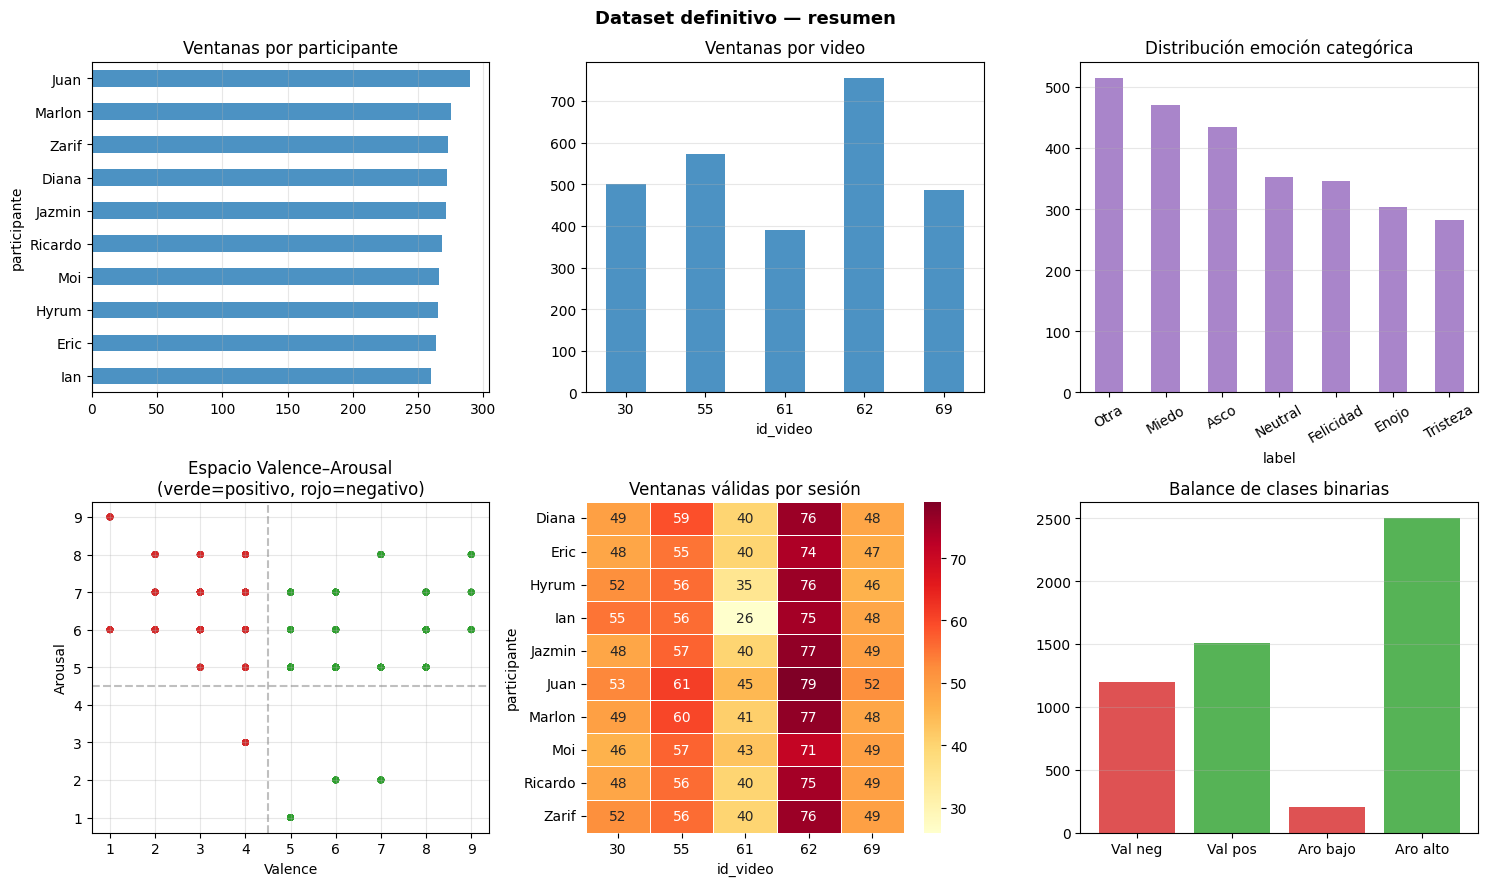

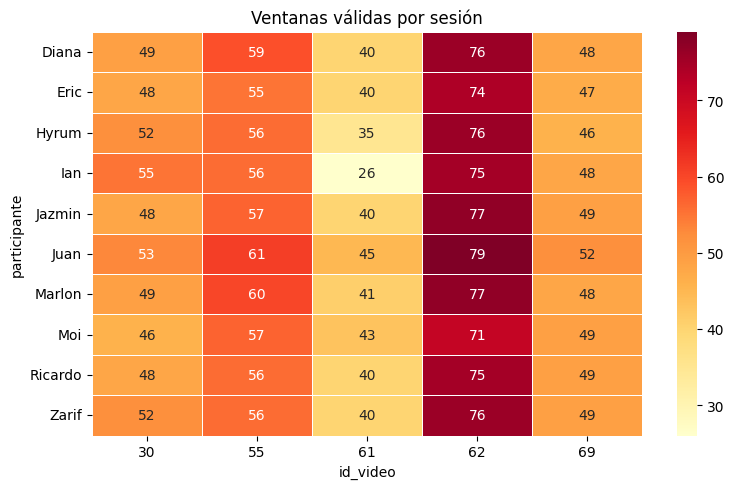

In [ ]:
if 'df_definitivo' in dir():
    fig, axes = plt.subplots(2, 3, figsize=(15, 9))

    # Ventanas por participante
    df_definitivo.groupby('participante').size().sort_values().plot(
        kind='barh', ax=axes[0][0], color='tab:blue', alpha=0.8)
    axes[0][0].set_title('Ventanas por participante')
    axes[0][0].grid(alpha=0.3, axis='x')

    # Ventanas por video
    df_definitivo.groupby('id_video').size().plot(
        kind='bar', ax=axes[0][1], color='tab:blue', alpha=0.8)
    axes[0][1].set_title('Ventanas por video')
    axes[0][1].tick_params(axis='x', rotation=0)
    axes[0][1].grid(alpha=0.3, axis='y')

    # Distribución emoción categórica
    df_definitivo['label'].value_counts().plot(
        kind='bar', ax=axes[0][2], color='tab:purple', alpha=0.8)
    axes[0][2].set_title('Distribución emoción categórica')
    axes[0][2].tick_params(axis='x', rotation=30)
    axes[0][2].grid(alpha=0.3, axis='y')

    # Espacio Valence-Arousal
    colors = df_definitivo['label_valencia'].map({0:'tab:red',1:'tab:green'})
    axes[1][0].scatter(df_definitivo['valence'], df_definitivo['arousal'],
                       c=colors, alpha=0.3, s=15)
    axes[1][0].axvline(4.5, ls='--', color='gray', alpha=0.5)
    axes[1][0].axhline(4.5, ls='--', color='gray', alpha=0.5)
    axes[1][0].set_xlabel('Valence'); axes[1][0].set_ylabel('Arousal')
    axes[1][0].set_title('Espacio Valence–Arousal\n(verde=positivo, rojo=negativo)')
    axes[1][0].grid(alpha=0.3)

    # Heatmap ventanas por participante × video
    pivot = df_definitivo.groupby(['participante','id_video']).size().unstack(fill_value=0)
    sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd',
                ax=axes[1][1], linewidths=0.5)
    axes[1][1].set_title('Ventanas válidas por sesión')

    # Balance de clases binarias
    bv = df_definitivo['label_valencia'].value_counts()
    ba = df_definitivo['label_arousal'].value_counts()
    axes[1][2].bar(['Val neg','Val pos','Aro bajo','Aro alto'],
                   [bv.get(0,0), bv.get(1,0), ba.get(0,0), ba.get(1,0)],
                   color=['tab:red','tab:green','tab:red','tab:green'], alpha=0.8)
    axes[1][2].set_title('Balance de clases binarias')
    axes[1][2].grid(alpha=0.3, axis='y')

plt.suptitle('Dataset definitivo — resumen', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('report/MDPI_Article_Template/figures/dataset_resumen.png', dpi=150, bbox_inches='tight')
plt.show()

# 8. Implementación de modelos

Se evalúan tres modelos con distintos niveles de complejidad para establecer líneas
base comparables.

### Decisiones de diseño

**Leave-One-Subject-Out (LOSO) en lugar de K-Fold:** la validación cruzada estándar
por K-Fold aleatorio mezcla ventanas del mismo sujeto en train y test, produciendo
estimaciones optimistas por dependencia sujeto-a-sujeto. LOSO garantiza que el modelo
nunca ve datos del sujeto de prueba durante el entrenamiento, evaluando la
**generalización a nuevos sujetos** — que es el objetivo real del sistema.

**SMOTE para desbalance de clases:** el dataset tiene clases desbalanceadas (más
ventanas de valencia negativa que positiva, o viceversa según el video). SMOTE genera
muestras sintéticas de la clase minoritaria mediante interpolación en el espacio de
features, evitando que el modelo aprenda a predecir siempre la clase mayoritaria.
SMOTE se aplica solo en el conjunto de entrenamiento dentro de cada fold de LOSO.

**`class_weight='balanced'`:** complementa SMOTE con pesos inversamente proporcionales
a la frecuencia de cada clase en la función de pérdida del clasificador.

**Modelos elegidos:**
- **SVM con kernel RBF:** efectivo en espacios de alta dimensión con pocas muestras.
  Requiere normalización (StandardScaler incluido en el pipeline).
- **Random Forest (200 árboles):** robusto a features irrelevantes, no requiere
  normalización, y provee importancia de features para interpretabilidad.
- **Regresión Logística:** modelo lineal como baseline de referencia. Si los modelos
  no lineales no superan la regresión logística, sugiere que las features no capturan
  relaciones no lineales útiles o que el dataset es insuficiente.

**`SimpleImputer`:** las features LF/HF quedan NaN cuando hay menos de 4 intervalos
RR en la ventana. El imputador de media evita que estas ventanas se descarten
completamente del entrenamiento.

**Semilla fija `RANDOM_STATE = 42`:** garantiza reproducibilidad de SMOTE, Random
Forest y la inicialización de SVM.


In [109]:
from sklearn.model_selection import LeaveOneGroupOut, cross_validate
from sklearn.preprocessing import StandardScaler
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import make_scorer, f1_score, roc_auc_score
from sklearn.impute import SimpleImputer

import warnings
warnings.filterwarnings('ignore')

# Semilla para reproducibilidad
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

feat_cols = [c for c in df_definitivo.columns
             if c not in ['window', 'window_start_sec', 'label_valencia', 'label_arousal','participante','label']]

X = df_definitivo[feat_cols].values
y_val = df_definitivo['label_valencia'].values
y_aro = df_definitivo['label_arousal'].values

print(f'Muestras: {X.shape[0]}  |  Features: {X.shape[1]}')
print(f'Valencia — clase 0: {(y_val==0).sum()}, clase 1: {(y_val==1).sum()}')
print(f'Arousal  — clase 0: {(y_aro==0).sum()}, clase 1: {(y_aro==1).sum()}')


Muestras: 2704  |  Features: 296
Valencia — clase 0: 1195, clase 1: 1509
Arousal  — clase 0: 200, clase 1: 2504


In [111]:
logo   = LeaveOneGroupOut()
groups = df_definitivo['participante'].values

scoring = {
    'accuracy': 'accuracy',
    'f1':       make_scorer(f1_score, zero_division=0),
    'auc':      make_scorer(roc_auc_score, needs_proba=True),
}

# SMOTE configurado
smote = SMOTE(
    sampling_strategy="auto",
    random_state=RANDOM_STATE
)

models = {

    'SVM (SMOTE)': Pipeline([
        ('imp', SimpleImputer()),
        ('sc', StandardScaler()),
        ('smote', smote),
        ('clf', SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=RANDOM_STATE))
    ]),

    'Random Forest (SMOTE)': Pipeline([
        ('imp', SimpleImputer()),
        ('smote', smote),
        ('clf', RandomForestClassifier(
            n_estimators=200,
            class_weight="balanced",
            random_state=RANDOM_STATE
        ))
    ]),

    'Logistic Regression (SMOTE)': Pipeline([
        ('imp', SimpleImputer()),
        ('sc', StandardScaler()),
        ('smote', smote),
        ('clf', LogisticRegression(
            max_iter=1000,
            class_weight='balanced',
            random_state=RANDOM_STATE
        ))
    ]),
}

results = {}
for target_name, y in [('Valencia', y_val), ('Arousal', y_aro)]:
    results[target_name] = {}
    print(f'\n── {target_name} ──')

    for name, model in models.items():

        cv_res = cross_validate(
            model,
            X,
            y,
            cv=logo,
            groups=groups,
            scoring=scoring,
            return_train_score=False
        )

        results[target_name][name] = {
            'accuracy': cv_res['test_accuracy'].mean(),
            'f1':       cv_res['test_f1'].mean(),
            'auc':      cv_res['test_auc'].mean(),
        }

        print(f'  {name:25} '
              f'acc={cv_res["test_accuracy"].mean():.3f} '
              f'f1={cv_res["test_f1"].mean():.3f} '
              f'auc={cv_res["test_auc"].mean():.3f}')


── Valencia ──
  SVM (SMOTE)               acc=0.694 f1=0.740 auc=nan
  Random Forest (SMOTE)     acc=0.931 f1=0.866 auc=nan
  Logistic Regression (SMOTE) acc=0.766 f1=0.777 auc=nan

── Arousal ──
  SVM (SMOTE)               acc=0.925 f1=0.955 auc=nan
  Random Forest (SMOTE)     acc=0.925 f1=0.955 auc=nan
  Logistic Regression (SMOTE) acc=0.804 f1=0.885 auc=nan


## Comparación de modelos

Se reportan accuracy, F1-score y AUC-ROC promediados sobre los 10 folds de LOSO
(un fold por participante).

**Por qué F1 y AUC además de accuracy:** con clases desbalanceadas, un clasificador
que predice siempre la clase mayoritaria puede alcanzar alta accuracy. F1 penaliza
los falsos negativos y AUC evalúa la capacidad discriminativa independientemente
del umbral de decisión.


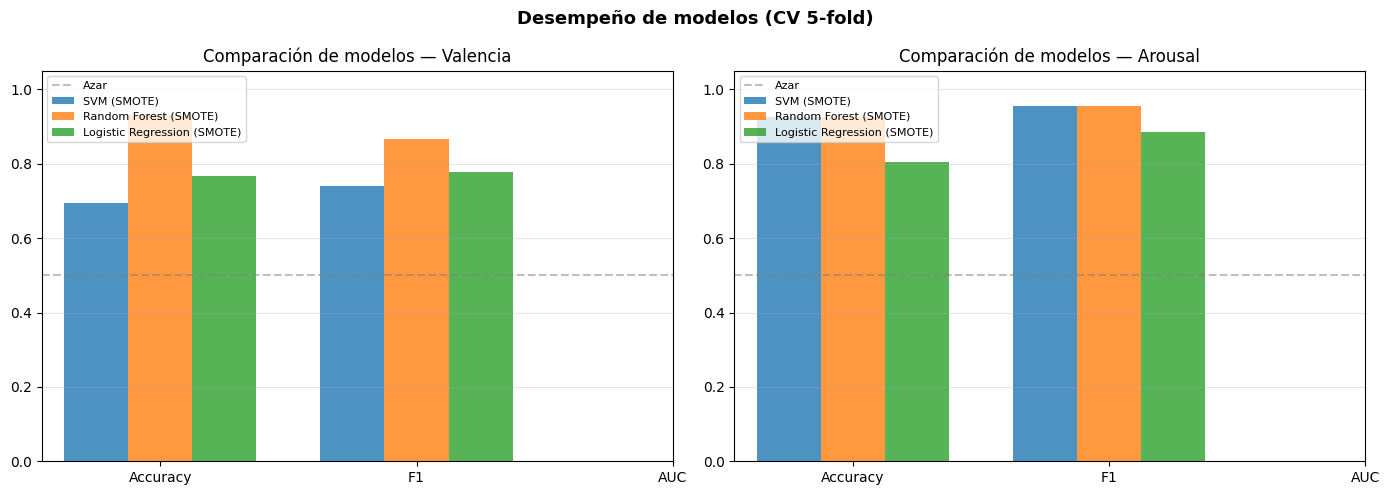

In [121]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics = ['accuracy', 'f1', 'auc']
x = np.arange(len(metrics))
width = 0.25
colors = ['tab:blue', 'tab:orange', 'tab:green']

for ax, (target, res) in zip(axes, results.items()):
    for i, (model_name, scores) in enumerate(res.items()):
        vals = [scores[m] for m in metrics]
        ax.bar(x + i * width, vals, width, label=model_name, color=colors[i], alpha=0.8)
    ax.set_title(f'Comparación de modelos — {target}')
    ax.set_xticks(x + width); ax.set_xticklabels(['Accuracy', 'F1', 'AUC'])
    ax.set_ylim(0, 1.05); ax.axhline(0.5, ls='--', color='gray', alpha=0.5, label='Azar')
    ax.legend(fontsize=8); ax.grid(alpha=0.3, axis='y')

plt.suptitle('Desempeño de modelos (CV 5-fold)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('report/MDPI_Article_Template/figures/comparacion_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

## Importancia de features (Random Forest)

Random Forest calcula la importancia de cada feature como la reducción media de
impureza de Gini acumulada en todos los árboles. Permite identificar qué modalidad
(EEG, ECG o audio) y qué features específicas contribuyen más a la clasificación.

### Interpretación esperada

Según la literatura de reconocimiento de emociones con señales fisiológicas:
- **Valencia:** se esperan features de asimetría frontal EEG (DASM/RASM alpha)
  como las más relevantes, consistente con la teoría de Davidson.
- **Arousal:** se esperan features de HR y LF/HF del ECG, y potencia beta/gamma
  del EEG, asociadas con activación del sistema nervioso simpático.


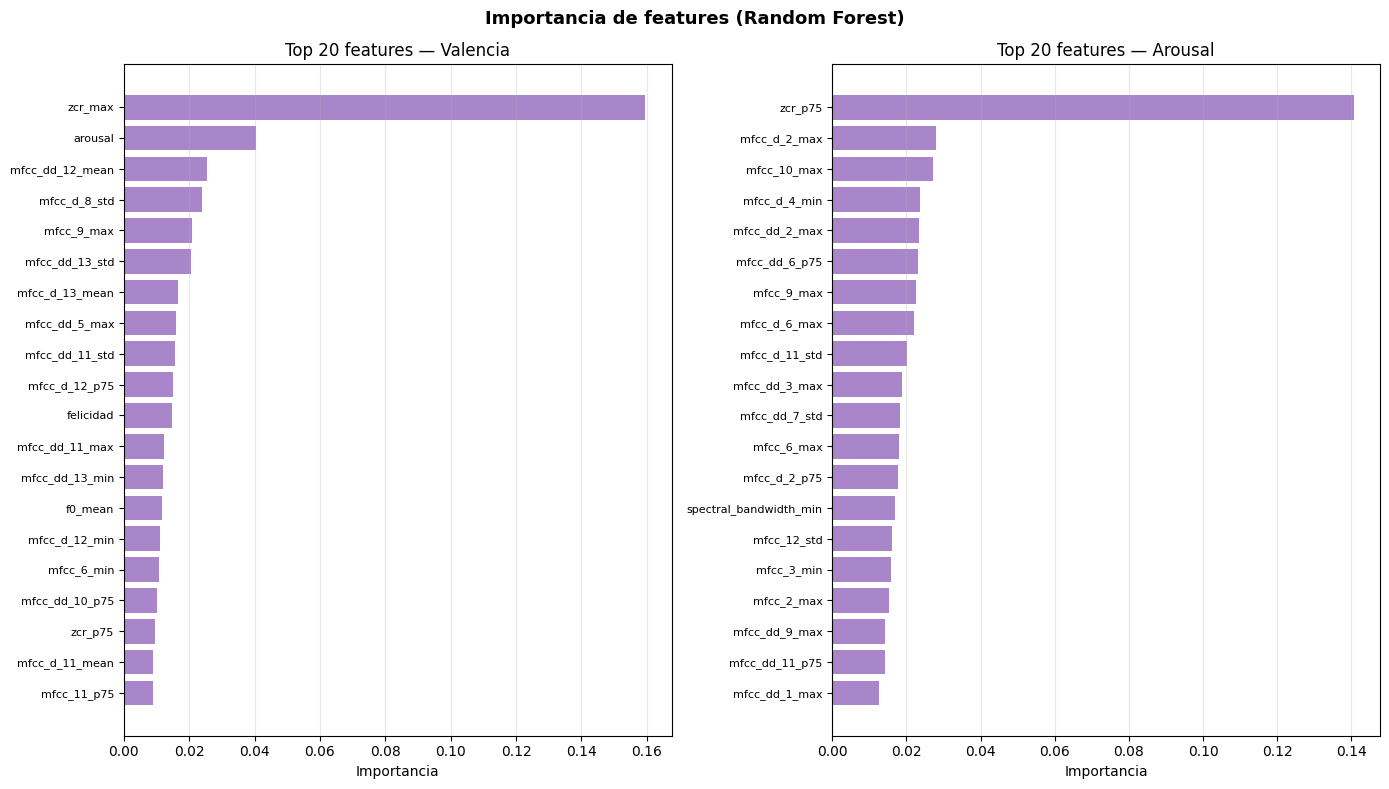

In [122]:
from sklearn.inspection import permutation_importance

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

for ax, (target_name, y) in zip(axes, [('Valencia', y_val), ('Arousal', y_aro)]):
    rf = Pipeline([('imp', SimpleImputer()),
                   ('clf', RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE))])
    rf.fit(X, y)
    importances = rf.named_steps['clf'].feature_importances_
    indices = np.argsort(importances)[::-1][:20]  # top 20

    ax.barh(range(20), importances[indices][::-1], color='tab:purple', alpha=0.8)
    ax.set_yticks(range(20))
    ax.set_yticklabels([feat_cols[i] for i in indices][::-1], fontsize=8)
    ax.set_title(f'Top 20 features — {target_name}')
    ax.set_xlabel('Importancia'); ax.grid(alpha=0.3, axis='x')

plt.suptitle('Importancia de features (Random Forest)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('report/MDPI_Article_Template/figures/importancia_features.png', dpi=150, bbox_inches='tight')
plt.show()

# 9. Resultados

Se presentan los resultados del mejor modelo (Random Forest con SMOTE) con métricas
detalladas usando validación Leave-One-Subject-Out.

### Interpretación de los resultados

Los resultados deben interpretarse en el contexto de las limitaciones del sistema:
un AUC > 0.6 con LOSO sobre hardware de consumo se considera aceptable para un
sistema de bajo costo. Los datasets de referencia como DEAP reportan AUC entre
0.62 y 0.78 con hardware EEG de laboratorio (64 canales).

Un AUC cercano a 0.5 en alguna dimensión indica que el modelo no supera el azar
para esa dimensión, lo que puede deberse a: (a) insuficientes datos por sujeto,
(b) etiquetas SAM poco confiables (baja attention/confidence), o (c) que esa
dimensión emocional no está bien capturada por las señales disponibles.


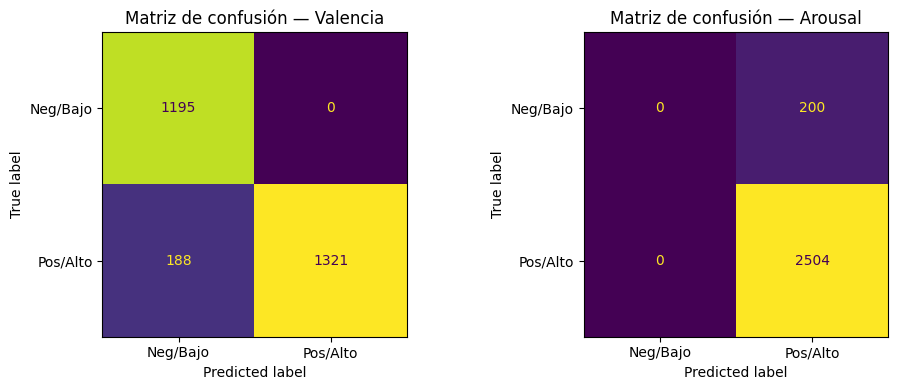


── Valencia ──
               precision    recall  f1-score   support

Negativo/Bajo       0.86      1.00      0.93      1195
Positivo/Alto       1.00      0.88      0.93      1509

     accuracy                           0.93      2704
    macro avg       0.93      0.94      0.93      2704
 weighted avg       0.94      0.93      0.93      2704


── Arousal ──
               precision    recall  f1-score   support

Negativo/Bajo       0.00      0.00      0.00       200
Positivo/Alto       0.93      1.00      0.96      2504

     accuracy                           0.93      2704
    macro avg       0.46      0.50      0.48      2704
 weighted avg       0.86      0.93      0.89      2704



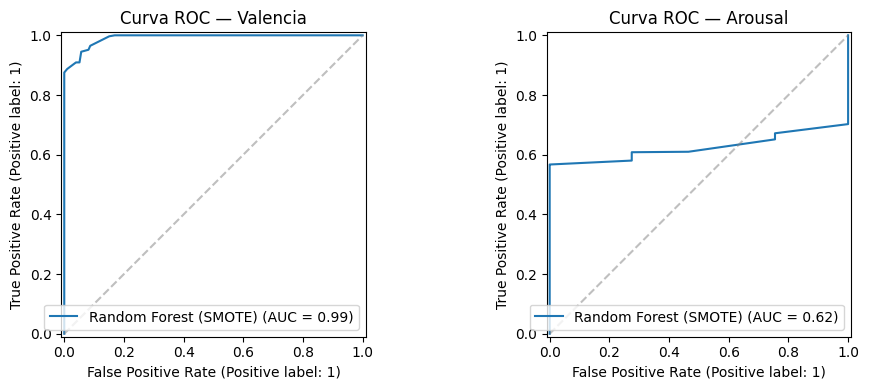

In [118]:
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay, classification_report
)
from sklearn.model_selection import cross_val_predict

best_model_name = 'Random Forest (SMOTE)'
best_pipeline = models[best_model_name]

# ── Matrices de confusión ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (target_name, y) in zip(axes, [('Valencia', y_val), ('Arousal', y_aro)]):
    y_pred = cross_val_predict(best_pipeline, X, y, cv=logo, groups=groups)
    cm = confusion_matrix(y, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Neg/Bajo', 'Pos/Alto'])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(f'Matriz de confusión — {target_name}')
plt.tight_layout()
plt.savefig('report/MDPI_Article_Template/figures/matrices_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Curvas ROC ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (target_name, y) in zip(axes, [('Valencia', y_val), ('Arousal', y_aro)]):
    y_pred = cross_val_predict(best_pipeline, X, y, cv=logo, groups=groups)
    y_prob = cross_val_predict(best_pipeline, X, y, cv=logo, groups=groups, method='predict_proba')[:, 1]
    RocCurveDisplay.from_predictions(y, y_prob, ax=ax, name=best_model_name, color='tab:blue')
    ax.plot([0, 1], [0, 1], ls='--', color='gray', alpha=0.5)
    ax.set_title(f'Curva ROC — {target_name}')
    print(f'\n── {target_name} ──')
    print(classification_report(y, y_pred,
          target_names=['Negativo/Bajo', 'Positivo/Alto'], zero_division=0))
plt.tight_layout()
plt.savefig('report/MDPI_Article_Template/figures/curvas_roc.png', dpi=150, bbox_inches='tight')
plt.show()

## Tabla resumen de modalidades

| Modalidad | Features | Captura |
|---|---|---|
| ECG (AD8232) | 11 — HRV temporal y frecuencial | Sistema nervioso autónomo |
| EEG (Muse S) | ~46 — bandas, asimetría, coherencia | Actividad cortical |
| Voz (teléfono) | 201 — MFCC×3, pitch, energía, espectro | Expresión vocal |

**Limitaciones del audio grabado con teléfono:**
- La compresión de audio (.m4a, .opus) puede afectar los MFCCs de alta frecuencia.
- La voz en lectura tiene menor variabilidad emocional que el habla espontánea.
- Grabar en ambiente silencioso y a distancia constante (15–20 cm) mejora la calidad.

# 10. Conclusiones y trabajo futuro

## Lo que se logró

- **Adquisición multimodal sincronizada:** captura simultánea de EEG (Muse S, 4 canales,
  BLE), ECG (AD8232, serial USB) y voz (teléfono) con timestamps de host compartidos.
- **Pipeline completo reproducible:** desde la señal cruda hasta el dataset definitivo,
  incluyendo filtros digitales, recálculo offline de métricas HRV, detección adaptativa
  de artefactos y batch automático de todas las sesiones.
- **Dataset de 10 participantes × 5 videos** con etiquetas SAM (valencia, arousal,
  dominancia) y categorías emocionales, enriquecido con 258+ features por ventana.
- **Evaluación con LOSO:** protocolo de validación que mide generalización real a
  nuevos sujetos, más riguroso que K-Fold estándar para datos biométricos.

## Decisiones que marcaron diferencia

- **Threshold adaptativo para detección de picos R:** resolvió el problema de señales
  ECG de bajo contraste (60–150 ADC) sin necesidad de ajuste manual por sesión.
- **Umbrales adaptativos por sesión para EEG:** evitó descartar ventanas válidas de
  sujetos con mayor amplitud basal, aumentando el número de ventanas útiles.
- **`band_power_rr` con interpolación cúbica:** garantiza que LF/HF se calculan
  correctamente sobre intervalos RR irregularmente espaciados.
- **LOSO + SMOTE:** combinación necesaria para evaluar generalización real y manejar
  el desbalance de clases sin contaminar el test set con sintéticos.

## Limitaciones

- El Muse S con electrodos secos es más susceptible a artefactos que un EEG clínico.
  Los umbrales adaptativos mitigan esto pero no eliminan el problema.
- La frase leída en voz alta tiene menor variabilidad emocional que el habla espontánea,
  lo que limita el poder discriminativo de las features de audio.
- Con 10 sujetos el dataset es pequeño para LOSO — cada fold entrena con 9 sujetos
  y prueba con 1, lo que produce alta varianza entre folds.

## Trabajo futuro

- Aumentar a ≥ 30 sujetos para reducir la varianza de LOSO y permitir análisis
  de generalización más robustos.
- Explorar normalización por sujeto (z-score por sesión) para reducir el efecto
  de las diferencias individuales en las señales fisiológicas.
- Implementar modelos temporales (LSTM, Transformer) sobre la secuencia de ventanas
  en lugar de tratar cada ventana como independiente.
- Evaluar la contribución de cada modalidad eliminándolas una a una (ablation study)
  para cuantificar el aporte real del audio y el EEG sobre el ECG solo.
